In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

# Load the Dataset

In [144]:
with open("df_H_event.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY_event = pickle.load(f)


In [145]:
df_H_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet,class,tau1_corr,tau2_corr
0,3.750918,0.149750,-2.504883,0.919922,0.001779,0.000654,1.097656,0.985840,0.997559,1.0,...,44.649644,0.836088,0.989466,1.0,1.0,-0.163912,-0.010534,1,1.196046,1.010646
1,3.908546,-0.357422,-2.585938,0.139526,0.006088,0.012403,0.971680,0.966797,0.997559,1.0,...,42.992980,0.780893,0.924580,0.0,0.0,-0.219107,-0.075420,1,1.280586,1.081572
6,3.735467,0.549683,1.355957,0.788574,0.002239,0.000944,1.020508,0.999023,0.999512,-1.0,...,31.457024,0.715766,0.830548,1.0,0.0,-0.284234,-0.169452,1,1.397104,1.204024
10,3.729789,0.430664,-0.860352,0.687012,0.011436,-0.025360,1.043945,0.988281,0.999512,1.0,...,38.147589,0.805584,0.544966,1.0,1.0,-0.194416,-0.455034,1,1.241336,1.834978
14,4.210932,1.539795,0.115631,8.835938,-0.506348,1.439453,0.895996,0.809082,-1.000000,1.0,...,38.603266,0.891623,0.630257,1.0,0.0,-0.108377,-0.369743,1,1.121550,1.586653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355215,4.048012,-0.148254,-0.296021,0.499023,0.006256,-0.002593,1.053711,0.997070,0.991211,1.0,...,43.611693,0.981467,0.758464,1.0,1.0,-0.018533,-0.241536,1,1.018883,1.318454
355216,3.832828,-1.078857,-1.057373,1.222656,-0.000417,-0.002056,1.019531,0.999023,0.994629,-1.0,...,35.609318,0.765776,0.802464,10.0,1.0,-0.234224,-0.197536,1,1.305866,1.246163
355217,4.351929,0.073349,-0.372009,13.562500,-0.004543,3.602661,0.901855,0.769531,-1.000000,-1.0,...,31.586895,0.952508,0.576930,2.0,1.0,-0.047492,-0.423070,1,1.049860,1.733314
355219,3.875998,0.232666,1.962646,5.148438,0.012688,0.028769,0.967773,0.999023,-1.000000,-1.0,...,41.002581,0.608163,0.805948,2.0,1.0,-0.391837,-0.194052,1,1.644296,1.240776


In [146]:
df_DY_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet,class,tau1_corr,tau2_corr
2,3.674162,0.875122,-0.090088,0.646484,-0.000050,0.000212,1.153320,0.914062,0.984863,-1.0,...,35.007927,0.974988,0.894771,1.0,10.0,-0.025012,-0.105229,0,1.025654,1.117604
6,3.694579,2.389160,1.977051,1.098633,-0.001568,0.005698,1.026367,0.996094,0.994629,1.0,...,41.035457,0.902500,0.901878,10.0,1.0,-0.097500,-0.098122,0,1.108034,1.108797
9,3.875156,-0.371704,0.386658,1.157227,0.000169,-0.001055,1.019531,0.999023,0.997559,-1.0,...,30.844352,0.929199,0.981132,10.0,1.0,-0.070801,-0.018868,0,1.076195,1.019230
17,3.964924,0.317871,1.018311,1.087891,-0.001331,-0.000872,0.998535,0.888672,0.994629,1.0,...,31.170514,0.929608,0.623410,1.0,0.0,-0.070392,-0.376590,0,1.075722,1.604080
25,3.511394,1.427734,0.866943,1.159180,0.000447,0.009053,0.967773,0.906738,0.992188,1.0,...,34.021892,0.743049,0.788913,1.0,10.0,-0.256951,-0.211087,0,1.345807,1.267566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335247,3.621049,0.668579,-1.771973,0.139526,0.001639,-0.000466,1.020508,0.988770,0.995605,-1.0,...,37.213682,0.833733,0.860432,0.0,0.0,-0.166267,-0.139568,0,1.199425,1.162207
335248,3.866463,0.207764,-0.460815,8.117188,0.030228,0.039980,0.803223,0.996582,-1.000000,-1.0,...,36.768819,0.730904,0.673113,1.0,0.0,-0.269096,-0.326887,0,1.368169,1.485634
335250,3.591280,0.836426,-0.882080,0.139526,-0.000064,0.000663,1.022461,0.869629,0.966797,-1.0,...,31.822474,0.893864,0.740058,0.0,10.0,-0.106136,-0.259942,0,1.118738,1.351246
335252,3.735802,-0.003489,-0.321960,7.296875,-0.002762,0.010244,0.840332,0.984863,-1.000000,-1.0,...,32.708994,0.924016,0.713003,1.0,10.0,-0.075984,-0.286997,0,1.082233,1.402519


# Model Setup

In [147]:
import time
import torch

from torch import nn, Tensor

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import matplotlib.pyplot as plt

from matplotlib import cm

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [148]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_covXX","MET_covXY",
    "MET_covYY","MET_significance","MET_sumEt","MET_sumPtUnclustered"
]

# gen_cols = ["gen_tau1_logpt", "gen_tau2_logpt"]

# mass_cols = ["inv_mass_reco", "inv_mass_tar"]

class_col = ["class"]

df_DY_event["class"] = 0  
df_H_event["class"] = 1

In [149]:
met_cols_reduced = [
    "MET_logpt",
    "MET_phi",
    "MET_significance",
    "MET_sumEt",
]

In [150]:
train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols_reduced
)

In [151]:
# Target: fattore di correzione

eps = 1e-8
for df in [df_DY_event, df_H_event]:
    df["tau1_corr"] = df["tau1_pt_gen"] / np.clip(df["tau1_pt_reco_corrPNet"], eps, None)
    df["tau2_corr"] = df["tau2_pt_gen"] / np.clip(df["tau2_pt_reco_corrPNet"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]


In [152]:
# Concateno DY e H: 
df_DY_event["class"] = 0  
df_H_event["class"]  = 1 

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)


# Model

In [153]:
# ============================================================
# 1 — MODEL (CFM) + LOSS + SAMPLING (NO scaling)
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split  


# -----------------------
# Reproducibility
# -----------------------
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# -----------------------
# Dataset
# -----------------------
class TabularFMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]


# -----------------------
# Time embedding
# -----------------------
class FourierTimeEmbedding(nn.Module):
    def __init__(self, embed_dim=64, max_freq=10.0):
        super().__init__()
        assert embed_dim % 2 == 0
        freqs = torch.linspace(1.0, max_freq, embed_dim // 2)
        self.register_buffer("freqs", freqs)

    def forward(self, t):
        # t: (B,) in [0,1]
        # returns (B, embed_dim)
        angles = 2.0 * math.pi * t[:, None] * self.freqs[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


# -----------------------
# Conditional velocity field v_theta(t, x_t, context)
# -----------------------
class ConditionalVelocityField(nn.Module):
    def __init__(
        self,
        x_dim: int,          # y-dim (2)
        context_dim: int,    # len(train_cols)
        hidden=(256, 256, 256),
        time_embed_dim=64,
        dropout=0.0,
    ):
        super().__init__()
        self.time_embed = FourierTimeEmbedding(embed_dim=time_embed_dim, max_freq=10.0)

        in_dim = x_dim + context_dim + time_embed_dim
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, x_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, t, x_t, context):
        # t: (B,)
        # x_t: (B, x_dim)
        # context: (B, context_dim)
        t_emb = self.time_embed(t)
        inp = torch.cat([x_t, context, t_emb], dim=-1)
        return self.net(inp)


# -----------------------
# Flow Matching loss (linear path) — NO scaling, NO log
# -----------------------
def fm_loss(model, context, x1, device):
    """
    context: (B, C)
    x1: (B, x_dim)   target y (NO scaling, NO log)
    """
    B, x_dim = x1.shape
    t = torch.rand(B, device=device)          # Uniform(0,1)
    x0 = torch.randn(B, x_dim, device=device) # base N(0,I)

    x_t = (1.0 - t)[:, None] * x0 + t[:, None] * x1
    v_star = x1 - x0

    v_pred = model(t, x_t, context)
    return torch.mean((v_pred - v_star) ** 2)


# -----------------------
# Sampling: integrate ODE from t=0 to t=1 (Euler)
# -----------------------
@torch.no_grad()
def sample_y(model, context, n_steps=50, device="cpu"):
    """
    context: (B, C) torch.float32
    returns x1_hat: (B, x_dim)
    """
    model.eval()
    B = context.shape[0]
    x_dim = model.net[-1].out_features

    x = torch.randn(B, x_dim, device=device)  # x(t=0)
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((B,), k * dt, device=device)
        v = model(t, x, context)
        x = x + dt * v  # Euler

    return x  # approx x(t=1)


# -----------------------
# Prediction helper (NO scaling) — uses sample_y
# -----------------------
@torch.no_grad()
def predict_tau_corr_general(
    df,
    res,                 # dict returned by train_conditional_flow_matching
    train_cols,
    y_cols,
    n_steps=60,
    batch_size=8192,
):
    """
    Predict y (tau corrections) for a dataframe, with NO scaling assumptions.
    Returns a DataFrame with columns: y_cols + '_pred' and tau1_corr_pred/tau2_corr_pred.

    res must contain:
      - res["model"]
      - res["device"]
    """
    model = res["model"]
    device = res.get("device", "cpu")

    X = df[train_cols].to_numpy(dtype=np.float32)
    X_t = torch.tensor(X, dtype=torch.float32, device=device)

    preds = []
    N = X_t.shape[0]

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        ctx = X_t[start:end]
        y_hat = sample_y(model, ctx, n_steps=n_steps, device=device)  # (b, x_dim)
        preds.append(y_hat.detach().cpu().numpy())

    y_pred = np.concatenate(preds, axis=0)  # (N, len(y_cols))

    out = pd.DataFrame(y_pred, columns=[f"{c}_pred" for c in y_cols], index=df.index)

    if len(y_cols) >= 2:
        out.rename(columns={
            f"{y_cols[0]}_pred": "tau1_corr_pred",
            f"{y_cols[1]}_pred": "tau2_corr_pred",
        }, inplace=True)

    return out


In [154]:
# ============================================================
# 2 — UTILITIES + TRAINING (NO scaling) + MASS PLOTS (2x2 TRAIN/TEST)
#     - NO balancing anywhere
#     - split is BLIND (NO stratify)
#     - mass plots in a single 2x2 grid (TRAIN/TEST x DY/Higgs)
# ============================================================


from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader


# ------------------------------------------------------------
# Utilities: split + early stopping
# ------------------------------------------------------------
def split_80_10_10(df, seed=42):
    """
    80/10/10 split WITHOUT stratify (blind split).
    This does NOT preserve class fractions by construction.
    """
    df_train, df_tmp = train_test_split(
        df, test_size=0.20, random_state=seed, shuffle=True, stratify=None
    )
    df_val, df_test = train_test_split(
        df_tmp, test_size=0.50, random_state=seed, shuffle=True, stratify=None
    )
    return (
        df_train.reset_index(drop=True),
        df_val.reset_index(drop=True),
        df_test.reset_index(drop=True),
    )


def summarize_splits(df_train, df_val, df_test, class_col="class"):
    def frac(df):
        if class_col not in df.columns:
            return {}
        vc = df[class_col].value_counts(normalize=True).to_dict()
        return {k: round(v, 3) for k, v in vc.items()}

    print("Split summary (NO stratify)")
    print(f"  Train: {len(df_train):>8}  frac: {frac(df_train)}")
    print(f"  Val  : {len(df_val):>8}  frac: {frac(df_val)}")
    print(f"  Test : {len(df_test):>8}  frac: {frac(df_test)}")


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.best = np.inf
        self.count = 0
        self.best_state = None

    def step(self, val_loss, model):
        improved = (self.best - val_loss) > self.min_delta
        if improved:
            self.best = val_loss
            self.count = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.count += 1
        return self.count >= self.patience


# ------------------------------------------------------------
# NO-SCALING: prepare arrays directly from df splits
# ------------------------------------------------------------
def prepare_arrays_noscale(df_train, df_val, df_test, train_cols, y_cols):
    """
    No scaling, no log.
    Returns Xtr/Xva/Xte, ytr/yva/yte in float32.
    """
    def get_X(df):
        return df[train_cols].to_numpy(dtype=np.float32)

    def get_y(df):
        return df[y_cols].to_numpy(dtype=np.float32)

    Xtr = get_X(df_train)
    Xva = get_X(df_val)
    Xte = get_X(df_test)

    ytr = get_y(df_train)
    yva = get_y(df_val)
    yte = get_y(df_test)

    scalers = {"mode": "NO_SCALING"}
    return Xtr, Xva, Xte, ytr, yva, yte, scalers


# ------------------------------------------------------------
# Mass helpers: invariant mass from (pt,eta,phi,m)
# ------------------------------------------------------------
def pt_eta_phi_m_to_p4(pt, eta, phi, m):
    """
    Arrays -> (E, px, py, pz)
    """
    pt  = np.asarray(pt)
    eta = np.asarray(eta)
    phi = np.asarray(phi)
    m   = np.asarray(m)

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)

    p2 = px**2 + py**2 + pz**2
    E  = np.sqrt(np.maximum(p2 + m**2, 0.0))
    return E, px, py, pz


def inv_mass_two_objects(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
    E1, px1, py1, pz1 = pt_eta_phi_m_to_p4(pt1, eta1, phi1, m1)
    E2, px2, py2, pz2 = pt_eta_phi_m_to_p4(pt2, eta2, phi2, m2)

    E  = E1 + E2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2

    m2_tot = E**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(np.maximum(m2_tot, 0.0))


def add_fm_mass_columns(
    df,
    df_pred,
    pt1_col="tau1_pt_reco_corrPNet",
    pt2_col="tau2_pt_reco_corrPNet",
    eta1_col="tau1_eta", phi1_col="tau1_phi", m1_col="tau1_mass",
    eta2_col="tau2_eta", phi2_col="tau2_phi", m2_col="tau2_mass",
    out_mass_col="inv_mass_FM",
    clip_corr=(0.0, 5.0),
):
    """
    Adds pt-corrected and invariant mass column using FM predictions.
    clip_corr is a safety clamp for pathological predictions.
    """
    df = df.copy()

    # predictions
    df["tau1_corr_pred"] = df_pred["tau1_corr_pred"].values
    df["tau2_corr_pred"] = df_pred["tau2_corr_pred"].values

    if clip_corr is not None:
        lo, hi = clip_corr
        df["tau1_corr_pred"] = df["tau1_corr_pred"].clip(lo, hi)
        df["tau2_corr_pred"] = df["tau2_corr_pred"].clip(lo, hi)

    # corrected pt
    df["tau1_pt_FM"] = df[pt1_col].values * df["tau1_corr_pred"].values
    df["tau2_pt_FM"] = df[pt2_col].values * df["tau2_corr_pred"].values

    # invariant mass
    df[out_mass_col] = inv_mass_two_objects(
        df["tau1_pt_FM"].values, df[eta1_col].values, df[phi1_col].values, df[m1_col].values,
        df["tau2_pt_FM"].values, df[eta2_col].values, df[phi2_col].values, df[m2_col].values,
    )
    return df


In [155]:
# ============================================================
# 3 — TRAINING (CFM, NO scaling) on (train_cols -> y_cols)
# ============================================================

from torch.utils.data import DataLoader

def train_conditional_flow_matching_noscale(
    df_ready,
    train_cols,
    y_cols,
    seed=42,
    device=None,
    # training hyperparams
    epochs=300,
    batch_size=4096,
    lr=2e-4,
    weight_decay=0.0,
    dropout=0.0,
    # model hyperparams
    hidden=(256, 256, 256),
    time_embed_dim=64,
    # early stopping
    patience=10,
    min_delta=0.0,
    # dataloader
    num_workers=0,
    pin_memory=True,
    verbose=1,
):
    """
    Train CFM (NO scaling, NO log) mapping context=train_cols -> target=y_cols.
    Uses blind 80/10/10 split (NO stratify).

    Returns res dict with:
      - res["model"], res["device"]
      - res["df_splits"] = (df_train, df_val, df_test)
      - res["scalers"] (placeholder "NO_SCALING")
      - res["loss_history"] (train/val)
      - res["train_cols"], res["y_cols"]
    """
    set_seed(seed)

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- split (blind) ---
    df_train, df_val, df_test = split_80_10_10(df_ready, seed=seed)
    if verbose:
        summarize_splits(df_train, df_val, df_test, class_col="class")

    # --- arrays (NO scaling) ---
    Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_arrays_noscale(
        df_train, df_val, df_test, train_cols=train_cols, y_cols=y_cols
    )

    # --- datasets/loaders ---
    ds_tr = TabularFMDataset(Xtr, ytr)
    ds_va = TabularFMDataset(Xva, yva)

    dl_tr = DataLoader(
        ds_tr, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory
    )
    dl_va = DataLoader(
        ds_va, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory
    )

    # --- model ---
    x_dim = ytr.shape[1]
    context_dim = Xtr.shape[1]
    model = ConditionalVelocityField(
        x_dim=x_dim,
        context_dim=context_dim,
        hidden=hidden,
        time_embed_dim=time_embed_dim,
        dropout=dropout,
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    hist_tr, hist_va = [], []

    # --- training loop ---
    for ep in range(1, epochs + 1):
        model.train()
        tr_losses = []

        for xb, yb in dl_tr:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            loss = fm_loss(model, xb, yb, device=device)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            tr_losses.append(loss.item())

        tr_loss = float(np.mean(tr_losses)) if len(tr_losses) else np.nan

        # --- val ---
        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in dl_va:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                loss = fm_loss(model, xb, yb, device=device)
                va_losses.append(loss.item())

        va_loss = float(np.mean(va_losses)) if len(va_losses) else np.nan

        hist_tr.append(tr_loss)
        hist_va.append(va_loss)

        if verbose and (ep % 20 == 0 or ep == 1):
            print(f"[ep {ep:03d}/{epochs}] train={tr_loss:.6f}  val={va_loss:.6f}")


        # --- early stopping on val ---
        if stopper.step(va_loss, model):
            if verbose:
                print(f"Early stopping at epoch {ep} (best val={stopper.best:.6f})")
            break

    # restore best weights
    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    res = {
        "model": model,
        "device": device,
        "df_splits": (df_train, df_val, df_test),
        "scalers": scalers,
        "loss_history": {"train": hist_tr, "val": hist_va},
        "train_cols": list(train_cols),
        "y_cols": list(y_cols),
        "seed": seed,
        "hyperparams": {
            "epochs": epochs, "batch_size": batch_size, "lr": lr,
            "weight_decay": weight_decay, "dropout": dropout,
            "hidden": tuple(hidden), "time_embed_dim": time_embed_dim,
            "patience": patience, "min_delta": min_delta,
        }
    }
    return res


In [156]:
res = train_conditional_flow_matching_noscale(
    df_ready=df_all,
    train_cols=train_cols,
    y_cols=y_cols,
    epochs=300,
    batch_size=4096,
    lr=2e-4,
    patience=10,
    seed=42,
    verbose=10,
)

Split summary (NO stratify)
  Train:   143567  frac: {1: 0.713, 0: 0.287}
  Val  :    17946  frac: {1: 0.719, 0: 0.281}
  Test :    17946  frac: {1: 0.713, 0: 0.287}
[ep 001/300] train=6.269045  val=1.329220
[ep 020/300] train=0.998876  val=0.965319
[ep 040/300] train=0.666520  val=0.749134
[ep 060/300] train=0.539447  val=0.527725
[ep 080/300] train=0.548433  val=0.502179
Early stopping at epoch 98 (best val=0.486935)


In [157]:
import os
import torch

def save_full_run(res, optimizer=None, folder="results/noscale_unbalanced"):
    """
    Saves:
      - model weights
      - optimizer state (if provided)
      - full checkpoint
      - loss history (CSV)
      - train/val/test splits (pickle, robust)
    """

    # Create folder if it doesn't exist
    os.makedirs(folder, exist_ok=True)

    # --------------------------------------------------
    # 1. Model weights
    # --------------------------------------------------
    torch.save(
        res["model"].state_dict(),
        os.path.join(folder, "model_state_dict.pt")
    )

    # --------------------------------------------------
    # 2. Optimizer state (optional)
    # --------------------------------------------------
    if optimizer is not None:
        torch.save(
            optimizer.state_dict(),
            os.path.join(folder, "optimizer_state_dict.pt")
        )

    # --------------------------------------------------
    # 3. Full checkpoint (model + config + loss)
    # --------------------------------------------------
    checkpoint = {
        "model_state_dict": res["model"].state_dict(),
        "hyperparams": res["hyperparams"],
        "seed": res["seed"],
        "train_cols": res["train_cols"],
        "y_cols": res["y_cols"],
        "loss_history": res["loss_history"],
    }

    torch.save(
        checkpoint,
        os.path.join(folder, "checkpoint_full.pt")
    )
    
    # --------------------------------------------------
    # 3bis. Save scalers (IMPORTANT for inference)
    # --------------------------------------------------
    if "scalers" in res and res["scalers"] is not None:
        torch.save(
            res["scalers"],
            os.path.join(folder, "scalers.pt")
        )


    # --------------------------------------------------
    # 4. Loss history as CSV (easy to plot later)
    # --------------------------------------------------
    loss_df = pd.DataFrame({
        "epoch": range(1, len(res["loss_history"]["train"]) + 1),
        "train_loss": res["loss_history"]["train"],
        "val_loss": res["loss_history"]["val"],
    })

    loss_df.to_csv(
        os.path.join(folder, "loss.csv"),
        index=False
    )

    # --------------------------------------------------
    # 5. Save splits (pickle = no dependency issues)
    # --------------------------------------------------
    df_train, df_val, df_test = res["df_splits"]

    df_train.to_pickle(os.path.join(folder, "df_train.pkl"))
    df_val.to_pickle(os.path.join(folder, "df_val.pkl"))
    df_test.to_pickle(os.path.join(folder, "df_test.pkl"))

    print(f"\n Run salvato correttamente in: {folder}\n")


In [158]:
save_full_run(res, folder="results/noscale_unbalanced")


 Run salvato correttamente in: results/noscale_unbalanced



In [159]:
df_train, df_val, df_test = res["df_splits"]

df_pred_test = predict_tau_corr_general(
    df=df_test,
    res=res,
    train_cols=train_cols,
    y_cols=y_cols,
    n_steps=60,
)


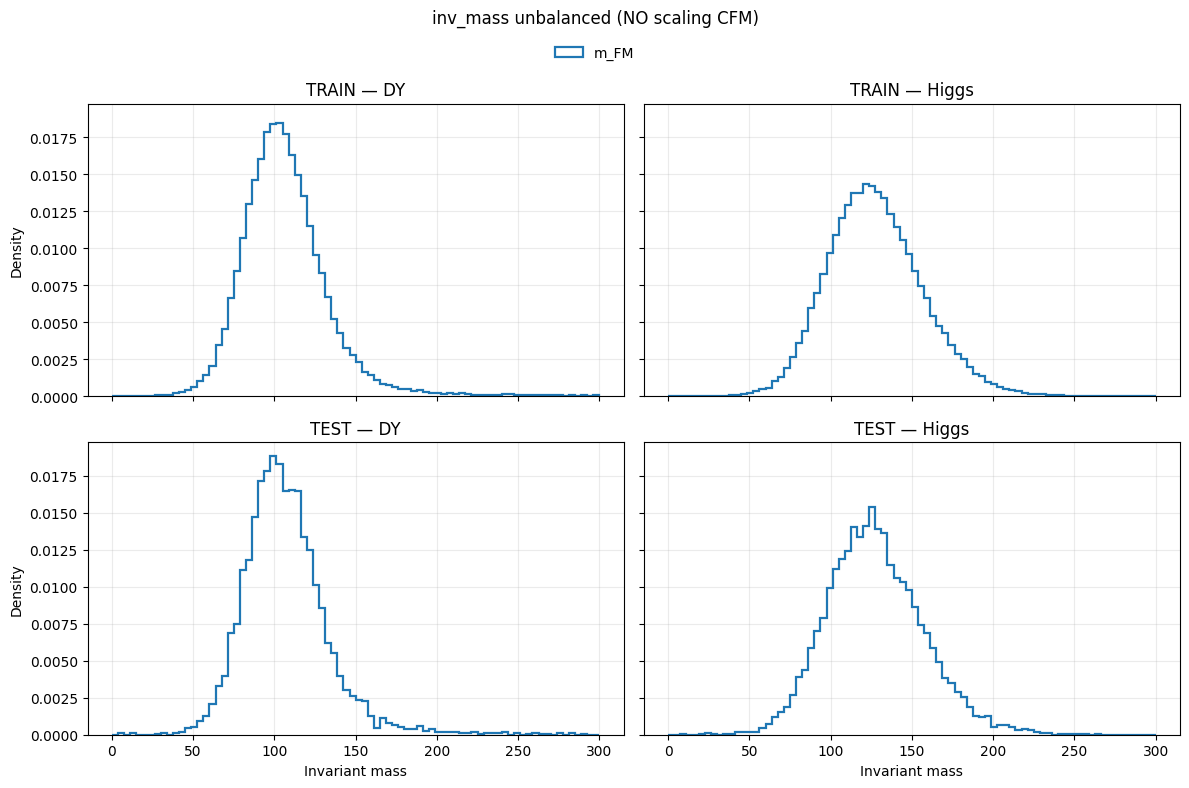

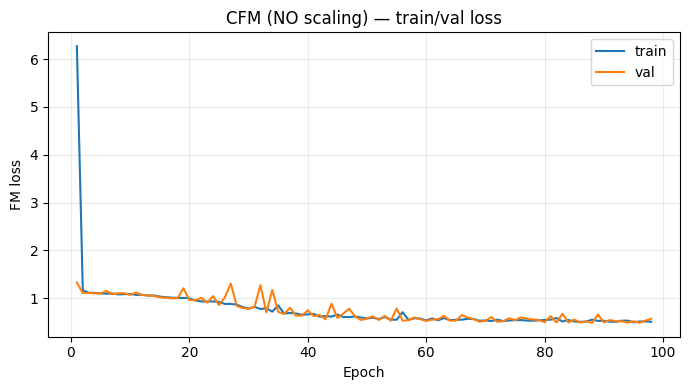

In [160]:
# ============================================================
# 4 — PLOTS: inv_mass_FM (2x2 DY/Higgs x TRAIN/TEST) + LOSS CURVES
# ============================================================

# -----------------------
# helper: robust class masks (DY/Higgs)
# -----------------------
def get_class_masks(df, class_col="class"):
    if class_col not in df.columns:
        raise ValueError(f"Missing '{class_col}' column.")
    c = df[class_col].to_numpy()
    m_dy = (c == 0)
    m_h  = (c == 1)
    return m_dy, m_h


# -----------------------
# 1) pull splits + predict + add inv_mass_FM
# -----------------------
df_train, df_val, df_test = res["df_splits"]

# predict tau corrections
df_pred_train = predict_tau_corr_general(df_train, res, res["train_cols"], res["y_cols"], n_steps=60, batch_size=8192)
df_pred_test  = predict_tau_corr_general(df_test,  res, res["train_cols"], res["y_cols"], n_steps=60, batch_size=8192)


# add FM mass columns
df_train_FM = add_fm_mass_columns(
    df_train, df_pred_train,
    pt1_col="tau1_pt_reco_corrPNet", pt2_col="tau2_pt_reco_corrPNet",
    eta1_col="tau1_eta", phi1_col="tau1_phi", m1_col="tau1_mass",
    eta2_col="tau2_eta", phi2_col="tau2_phi", m2_col="tau2_mass",
    out_mass_col="inv_mass_FM",
    clip_corr=(0.0, 5.0),
)

df_test_FM = add_fm_mass_columns(
    df_test, df_pred_test,
    pt1_col="tau1_pt_reco_corrPNet", pt2_col="tau2_pt_reco_corrPNet",
    eta1_col="tau1_eta", phi1_col="tau1_phi", m1_col="tau1_mass",
    eta2_col="tau2_eta", phi2_col="tau2_phi", m2_col="tau2_mass",
    out_mass_col="inv_mass_FM",
    clip_corr=(0.0, 5.0),
)

# -----------------------
# 2) 2x2 mass plots: (row=train/test) x (col=DY/Higgs)
# -----------------------
def plot_mass_grid_2x2(df_tr, df_te, class_col="class",
                      reco_col="inv_mass_reco", tar_col="inv_mass_tar", fm_col="inv_mass_FM",
                      bins=80, m_range=None, density=True, suptitle="Invariant mass distributions"):

    m_dy_tr, m_h_tr = get_class_masks(df_tr, class_col=class_col)
    m_dy_te, m_h_te = get_class_masks(df_te, class_col=class_col)

    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    fig.suptitle(suptitle)

    panels = [
        ("TRAIN — DY",    df_tr[m_dy_tr], axs[0, 0]),
        ("TRAIN — Higgs", df_tr[m_h_tr],  axs[0, 1]),
        ("TEST — DY",     df_te[m_dy_te], axs[1, 0]),
        ("TEST — Higgs",  df_te[m_h_te],  axs[1, 1]),
    ]

    for title, dfi, ax in panels:
        # drop NaNs
        reco = dfi[reco_col].to_numpy()
        tar  = dfi[tar_col].to_numpy()
        fm   = dfi[fm_col].to_numpy()
        reco = reco[np.isfinite(reco)]
        tar  = tar[np.isfinite(tar)]
        fm   = fm[np.isfinite(fm)]

     #   ax.hist(reco, bins=bins, range=m_range, histtype="step", density=density, linewidth=1.6, label="m_reco")
     #   ax.hist(tar,  bins=bins, range=m_range, histtype="step", density=density, linewidth=1.6, label="m_target")
        ax.hist(fm,   bins=bins, range=m_range, histtype="step", density=density, linewidth=1.6, label="m_FM")

        ax.set_title(title)
        ax.grid(True, alpha=0.25)

    for ax in axs[1, :]:
        ax.set_xlabel("Invariant mass")
    for ax in axs[:, 0]:
        ax.set_ylabel("Density" if density else "Counts")

    # one legend for the whole figure
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.95))
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

fig_mass = plot_mass_grid_2x2(
    df_train_FM, df_test_FM,
    class_col="class",
   # reco_col="inv_mass_reco",
   # tar_col="inv_mass_tar",
    fm_col="inv_mass_FM",
    bins=80,
    m_range=(0,300),     
    density=True,
    suptitle="inv_mass unbalanced (NO scaling CFM)",
)

plt.show()

# -----------------------
# 3) Loss curves (train/val vs epoch)
# -----------------------
def plot_loss_curves(res, title="CFM loss vs epochs"):
    tr = res["loss_history"]["train"]
    va = res["loss_history"]["val"]
    e_tr = np.arange(1, len(tr) + 1)
    e_va = np.arange(1, len(va) + 1)

    fig = plt.figure(figsize=(7, 4))
    plt.plot(e_tr, tr, label="train")
    plt.plot(e_va, va, label="val")
    plt.xlabel("Epoch")
    plt.ylabel("FM loss")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    return fig

fig_loss = plot_loss_curves(res, title="CFM (NO scaling) — train/val loss")
plt.show()


In [161]:
# ============================================================
# 3bis — PREP ARRAYS: X global-scaler, y local-scaler (DY vs Higgs)
# ============================================================
from sklearn.preprocessing import StandardScaler

def _infer_class_masks(df, class_col="class"):
    """
    Returns boolean masks (mask_DY, mask_H) aligned to df rows.
    Preferred: numeric labels 0=DY, 1=H.
    Fallback: string labels containing 'dy'/'drell' and 'higgs'.
    """
    if class_col not in df.columns:
        raise ValueError(f"Missing '{class_col}' column for local y-scaling.")

    c = df[class_col]

    # --- numeric: expected case (0/1) ---
    if np.issubdtype(c.dtype, np.number):
        vals = c.to_numpy()
        m_dy = (vals == 0)
        m_h  = (vals == 1)

        # sanity: if not all rows covered, try generic 2-class mapping
        if not np.all(m_dy | m_h):
            uniq = np.unique(vals[~np.isnan(vals)])
            if len(uniq) == 2:
                dy_label = np.min(uniq)
                h_label  = np.max(uniq)
                m_dy = (vals == dy_label)
                m_h  = (vals == h_label)
            else:
                raise ValueError(f"Unexpected numeric classes in '{class_col}': {uniq}")

        return m_dy, m_h

    # --- string fallback ---
    s = c.astype(str).str.lower()
    m_dy = s.str.contains("dy") | s.str.contains("drell")
    m_h  = s.str.contains("higgs")

    # sanity checks
    if (m_dy & m_h).any():
        raise ValueError("Overlapping DY/H masks inferred from string labels (check class column).")
    if (m_dy | m_h).sum() == 0:
        raise ValueError("Could not infer any DY/H rows from string labels (expected DY/drell and Higgs).")

    return m_dy.to_numpy(), m_h.to_numpy()


def _apply_local_scaler(y, mask_dy, mask_h, scaler_dy, scaler_h):
    """
    Apply two different scalers to y row-wise depending on masks.
    Any row not in DY/H gets left unscaled (but we warn).
    """
    y = np.asarray(y, dtype=np.float32)
    y_out = y.copy()

    if mask_dy.sum() > 0:
        y_out[mask_dy] = scaler_dy.transform(y[mask_dy]).astype(np.float32)
    if mask_h.sum() > 0:
        y_out[mask_h]  = scaler_h.transform(y[mask_h]).astype(np.float32)

    other = ~(mask_dy | mask_h)
    if other.sum() > 0:
        print(f"[WARN] {other.sum()} rows are neither DY nor Higgs in local y-scaling; left unscaled.")

    return y_out


def prepare_arrays_scaled_mixed(df_train, df_val, df_test, train_cols, y_cols, class_col="class"):
    """
    X: StandardScaler GLOBAL (fit on TRAIN, DY+H together)
    y: StandardScaler LOCAL (fit separately on TRAIN: DY vs Higgs)

    Returns:
      Xtr,Xva,Xte (scaled), ytr,yva,yte (scaled locally), scalers dict
    """
    # --- raw arrays ---
    Xtr_raw = df_train[train_cols].to_numpy(dtype=np.float32)
    Xva_raw = df_val[train_cols].to_numpy(dtype=np.float32)
    Xte_raw = df_test[train_cols].to_numpy(dtype=np.float32)

    ytr_raw = df_train[y_cols].to_numpy(dtype=np.float32)
    yva_raw = df_val[y_cols].to_numpy(dtype=np.float32)
    yte_raw = df_test[y_cols].to_numpy(dtype=np.float32)

    # --- GLOBAL X scaler (fit on TRAIN only) ---
    x_scaler = StandardScaler()
    Xtr = x_scaler.fit_transform(Xtr_raw).astype(np.float32)
    Xva = x_scaler.transform(Xva_raw).astype(np.float32)
    Xte = x_scaler.transform(Xte_raw).astype(np.float32)

    # --- LOCAL y scalers (fit on TRAIN only, separately) ---
    m_dy_tr, m_h_tr = _infer_class_masks(df_train, class_col=class_col)

    if m_dy_tr.sum() < 10 or m_h_tr.sum() < 10:
        print(f"[WARN] Low stats for local y-scaling: DY={m_dy_tr.sum()}, H={m_h_tr.sum()}")

    y_scaler_dy = StandardScaler()
    y_scaler_h  = StandardScaler()

    # Fit separately (must have >0 rows)
    y_scaler_dy.fit(ytr_raw[m_dy_tr] if m_dy_tr.sum() > 0 else ytr_raw)
    y_scaler_h.fit( ytr_raw[m_h_tr]  if m_h_tr.sum() > 0 else ytr_raw)

    # --- apply to TRAIN/VAL/TEST using each row's class ---
    m_dy_va, m_h_va = _infer_class_masks(df_val,  class_col=class_col)
    m_dy_te, m_h_te = _infer_class_masks(df_test, class_col=class_col)

    ytr = _apply_local_scaler(ytr_raw, m_dy_tr, m_h_tr, y_scaler_dy, y_scaler_h)
    yva = _apply_local_scaler(yva_raw, m_dy_va, m_h_va, y_scaler_dy, y_scaler_h)
    yte = _apply_local_scaler(yte_raw, m_dy_te, m_h_te, y_scaler_dy, y_scaler_h)

    scalers = {
        "mode": "X_GLOBAL__Y_LOCAL",
        "class_col": class_col,
        "x_scaler": x_scaler,
        "y_scaler_dy": y_scaler_dy,
        "y_scaler_h": y_scaler_h,
    }

    return Xtr, Xva, Xte, ytr, yva, yte, scalers


In [162]:
# ============================================================
# 3ter — PREDICT helper (X global-scaler + y local inverse)
# ============================================================
@torch.no_grad()
def predict_tau_corr_general_scaled_mixed(
    df,
    res,
    train_cols=None,
    y_cols=None,
    n_steps=60,
    batch_size=8192,
):
    """
    Predictor for mode: X_GLOBAL__Y_LOCAL

    Steps:
      1) X_raw -> X_scaled via global x_scaler
      2) sample y_hat_scaled with the CFM model (in scaled y space)
      3) inverse-transform y_hat_scaled -> y_hat (original space) using:
           - y_scaler_dy for rows with class==0 (DY)
           - y_scaler_h  for rows with class==1 (H)

    Returns:
      DataFrame with columns:
        - <y_col>_pred for each y_col
        - and (if len(y_cols)>=2) also tau1_corr_pred, tau2_corr_pred
    """
    model = res["model"]
    device = res.get("device", "cpu")

    # prefer res-stored columns to avoid mismatches
    if train_cols is None:
        train_cols = res.get("train_cols")
    if y_cols is None:
        y_cols = res.get("y_cols")
    if train_cols is None or y_cols is None:
        raise ValueError("train_cols/y_cols must be provided or stored in res['train_cols']/res['y_cols'].")

    scalers = res.get("scalers", {})
    if scalers.get("mode") != "X_GLOBAL__Y_LOCAL":
        raise ValueError("This predictor requires res['scalers']['mode'] == 'X_GLOBAL__Y_LOCAL'.")

    class_col = scalers.get("class_col", "class")
    if class_col not in df.columns:
        raise ValueError(f"Missing '{class_col}' column in df for local inverse scaling.")

    x_scaler    = scalers["x_scaler"]
    y_scaler_dy = scalers["y_scaler_dy"]
    y_scaler_h  = scalers["y_scaler_h"]

    # --- scale X globally ---
    X_raw = df[train_cols].to_numpy(dtype=np.float32)
    X = x_scaler.transform(X_raw).astype(np.float32)
    X_t = torch.tensor(X, dtype=torch.float32, device=device)

    # --- sample in scaled y space ---
    preds_scaled = []
    N = X_t.shape[0]
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        ctx = X_t[start:end]
        y_hat_scaled = sample_y(model, ctx, n_steps=n_steps, device=device)  # (b, y_dim)
        preds_scaled.append(y_hat_scaled.detach().cpu().numpy())

    y_scaled = np.concatenate(preds_scaled, axis=0).astype(np.float32)  # (N, y_dim)

    # --- local inverse scaling: scaled -> original ---
    m_dy, m_h = _infer_class_masks(df, class_col=class_col)
    y = np.empty_like(y_scaled, dtype=np.float32)

    if m_dy.sum() > 0:
        y[m_dy] = y_scaler_dy.inverse_transform(y_scaled[m_dy]).astype(np.float32)
    if m_h.sum() > 0:
        y[m_h]  = y_scaler_h.inverse_transform(y_scaled[m_h]).astype(np.float32)

    other = ~(m_dy | m_h)
    if other.sum() > 0:
        # shouldn't happen; keep scaled values but warn
        print(f"[WARN] {other.sum()} rows are neither DY nor Higgs; leaving y in scaled space for those rows.")
        y[other] = y_scaled[other]

    # --- output dataframe ---
    out = pd.DataFrame(y, columns=[f"{c}_pred" for c in y_cols], index=df.index)

    if len(y_cols) >= 2:
        out.rename(columns={
            f"{y_cols[0]}_pred": "tau1_corr_pred",
            f"{y_cols[1]}_pred": "tau2_corr_pred",
        }, inplace=True)

    return out


In [163]:
Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_arrays_scaled_mixed(
    df_train, df_val, df_test,
    train_cols=train_cols,
    y_cols=y_cols,
    class_col="class",
)


In [164]:
# ============================================================
# TRAINING CFM — X global scaled, y local scaled
# ============================================================
import numpy as np
import torch
from torch.utils.data import DataLoader

SEED = 42
set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
use_cuda = (device == "cuda")

# --- Dataset ---
ds_tr = TabularFMDataset(Xtr, ytr)
ds_va = TabularFMDataset(Xva, yva)

dl_tr = DataLoader(
    ds_tr,
    batch_size=4096,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=use_cuda,
)
dl_va = DataLoader(
    ds_va,
    batch_size=4096,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=use_cuda,
)

# --- Model ---
x_dim = ytr.shape[1]
context_dim = Xtr.shape[1]

model = ConditionalVelocityField(
    x_dim=x_dim,
    context_dim=context_dim,
    hidden=(256, 256, 256),
    time_embed_dim=64,
    dropout=0.0,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.0)
stopper = EarlyStopping(patience=30, min_delta=1e-4)

epochs = 300
hist_tr, hist_va = [], []

# -----------------------
# Training loop
# -----------------------
for ep in range(1, epochs + 1):

    # ---- TRAIN ----
    model.train()
    losses_tr = []

    for xb, yb in dl_tr:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        loss = fm_loss(model, xb, yb, device=device)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        losses_tr.append(loss.item())

    tr_loss = float(np.mean(losses_tr)) if len(losses_tr) else float("nan")

    # ---- VALIDATION ----
    model.eval()
    losses_va = []
    with torch.no_grad():
        for xb, yb in dl_va:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            loss = fm_loss(model, xb, yb, device=device)
            losses_va.append(loss.item())

    va_loss = float(np.mean(losses_va)) if len(losses_va) else float("nan")

    hist_tr.append(tr_loss)
    hist_va.append(va_loss)

    # stampa ogni 20 epoche
    if ep % 20 == 0 or ep == 1:
        print(f"[ep {ep:03d}/{epochs}] train={tr_loss:.6f}  val={va_loss:.6f}")

    # early stopping
    if stopper.step(va_loss, model):
        print(f"Early stopping at epoch {ep}  (best val={stopper.best:.6f})")
        break

# restore best weights
if stopper.best_state is not None:
    model.load_state_dict(stopper.best_state)

# -----------------------
# res dict (IMPORTANT: include scalers)
# -----------------------
res_scaled = {
    "model": model,
    "device": device,
    "scalers": scalers,  
    "df_splits": (df_train, df_val, df_test),
    "loss_history": {"train": hist_tr, "val": hist_va},
    "train_cols": list(train_cols),
    "y_cols": list(y_cols),
    "seed": SEED,
    "hyperparams": {
        "epochs": epochs,
        "batch_size": 4096,
        "lr": 2e-4,
        "weight_decay": 0.0,
        "hidden": (256, 256, 256),
        "time_embed_dim": 64,
        "dropout": 0.0,
        "patience": 30,
        "min_delta": 1e-4,
        "n_steps_sampling_default": 60,
        "scaling_mode": scalers.get("mode", "UNKNOWN"),
    },
}


[ep 001/300] train=1.948242  val=1.879098
[ep 020/300] train=1.135640  val=1.122944
[ep 040/300] train=1.089427  val=1.094432
[ep 060/300] train=1.036848  val=1.044202
[ep 080/300] train=1.019764  val=1.044350
[ep 100/300] train=1.015519  val=1.003880
[ep 120/300] train=1.006557  val=1.015506
[ep 140/300] train=1.000842  val=1.005821
[ep 160/300] train=0.989825  val=0.989662
[ep 180/300] train=0.985065  val=0.970816
[ep 200/300] train=0.973934  val=0.973216
[ep 220/300] train=0.959160  val=0.966875
[ep 240/300] train=0.955602  val=0.948884
[ep 260/300] train=0.953709  val=0.965003
[ep 280/300] train=0.940886  val=0.942676
[ep 300/300] train=0.918408  val=0.936570


In [165]:
save_full_run(
    res_scaled,
  #  optimizer=optimizer,
    folder="results/mixedscale_unbalanced"
)



 Run salvato correttamente in: results/mixedscale_unbalanced



In [166]:
assert "class" in df_test.columns

In [167]:
df_pred_test = predict_tau_corr_general_scaled_mixed(
    df=df_test,
    res=res_scaled,
    train_cols=res_scaled["train_cols"],
    y_cols=res_scaled["y_cols"],
    n_steps=60,
)


In [168]:
df_test_FM = add_fm_mass_columns(
    df_test,
    df_pred_test,
    out_mass_col="inv_mass_FM",
)


In [169]:
# ============================================================
# PREP ARRAYS: X global scaler + y global scaler
# ============================================================
from sklearn.preprocessing import StandardScaler

def prepare_arrays_scaled_global(df_train, df_val, df_test, train_cols, y_cols):
    """
    X: StandardScaler GLOBAL (fit on TRAIN, DY+H together)
    y: StandardScaler GLOBAL (fit on TRAIN, DY+H together)

    Returns:
      Xtr,Xva,Xte (scaled), ytr,yva,yte (scaled), scalers dict
    """
    # --- raw arrays ---
    Xtr_raw = df_train[train_cols].to_numpy(dtype=np.float32)
    Xva_raw = df_val[train_cols].to_numpy(dtype=np.float32)
    Xte_raw = df_test[train_cols].to_numpy(dtype=np.float32)

    ytr_raw = df_train[y_cols].to_numpy(dtype=np.float32)
    yva_raw = df_val[y_cols].to_numpy(dtype=np.float32)
    yte_raw = df_test[y_cols].to_numpy(dtype=np.float32)

    # --- quick sanity (warn only) ---
    if not np.isfinite(Xtr_raw).all():
        print("[WARN] Non-finite values found in Xtr_raw.")
    if not np.isfinite(ytr_raw).all():
        print("[WARN] Non-finite values found in ytr_raw.")

    # --- scalers (fit only on TRAIN) ---
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    Xtr = x_scaler.fit_transform(Xtr_raw).astype(np.float32)
    Xva = x_scaler.transform(Xva_raw).astype(np.float32)
    Xte = x_scaler.transform(Xte_raw).astype(np.float32)

    ytr = y_scaler.fit_transform(ytr_raw).astype(np.float32)
    yva = y_scaler.transform(yva_raw).astype(np.float32)
    yte = y_scaler.transform(yte_raw).astype(np.float32)

    scalers = {
        "mode": "X_GLOBAL__Y_GLOBAL",
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "train_cols": list(train_cols),
        "y_cols": list(y_cols),
    }

    return Xtr, Xva, Xte, ytr, yva, yte, scalers



In [170]:
# ============================================================
# PREDICT: X global transform + y global inverse_transform
# ============================================================
@torch.no_grad()
def predict_tau_corr_general_scaled_global(
    df,
    res,
    train_cols=None,
    y_cols=None,
    n_steps=60,
    batch_size=8192,
):
    """
    Predictor for mode: X_GLOBAL__Y_GLOBAL

    Steps:
      1) X_raw -> X_scaled via global x_scaler
      2) sample y_hat_scaled with the CFM model (in scaled y space)
      3) inverse-transform y_hat_scaled -> y_hat (original space) using global y_scaler

    Returns:
      DataFrame with columns:
        - <y_col>_pred for each y_col
        - and (if len(y_cols)>=2) tau1_corr_pred, tau2_corr_pred
    """
    model = res["model"]
    device = res.get("device", "cpu")

    # prefer res-stored columns to avoid mismatches
    if train_cols is None:
        train_cols = res.get("train_cols")
    if y_cols is None:
        y_cols = res.get("y_cols")
    if train_cols is None or y_cols is None:
        raise ValueError("train_cols/y_cols must be provided or stored in res['train_cols']/res['y_cols'].")

    scalers = res.get("scalers", {})
    if scalers.get("mode") != "X_GLOBAL__Y_GLOBAL":
        raise ValueError("This predictor requires res['scalers']['mode'] == 'X_GLOBAL__Y_GLOBAL'.")

    x_scaler = scalers["x_scaler"]
    y_scaler = scalers["y_scaler"]

    # --- scale X globally ---
    X_raw = df[train_cols].to_numpy(dtype=np.float32)
    X = x_scaler.transform(X_raw).astype(np.float32)
    X_t = torch.tensor(X, dtype=torch.float32, device=device)

    # --- sample in scaled y space ---
    preds_scaled = []
    N = X_t.shape[0]
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        ctx = X_t[start:end]
        y_hat_scaled = sample_y(model, ctx, n_steps=n_steps, device=device)  # (b, y_dim)
        preds_scaled.append(y_hat_scaled.detach().cpu().numpy())

    y_scaled = np.concatenate(preds_scaled, axis=0).astype(np.float32)

    # sanity: dimensionality check
    if y_scaled.shape[1] != len(y_cols):
        raise ValueError(f"Predicted y_dim={y_scaled.shape[1]} but len(y_cols)={len(y_cols)}. Check model/y_cols.")

    # --- inverse y scaling to original space ---
    y = y_scaler.inverse_transform(y_scaled).astype(np.float32)

    # --- output dataframe ---
    out = pd.DataFrame(y, columns=[f"{c}_pred" for c in y_cols], index=df.index)

    if len(y_cols) >= 2:
        out.rename(columns={
            f"{y_cols[0]}_pred": "tau1_corr_pred",
            f"{y_cols[1]}_pred": "tau2_corr_pred",
        }, inplace=True)

    return out


In [171]:
Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_arrays_scaled_global(
    df_train, df_val, df_test,
    train_cols=train_cols,
    y_cols=y_cols,
)


In [172]:
# check 
print("Xtr mean/std (first 3):", Xtr[:, :3].mean(0), Xtr[:, :3].std(0))
print("ytr mean/std:", ytr.mean(0), ytr.std(0))
print("scaling mode:", scalers["mode"])


Xtr mean/std (first 3): [-4.2513362e-09 -1.4241976e-08  5.3141702e-10] [1. 1. 1.]
ytr mean/std: [-4.782753e-10 -4.251336e-09] [1. 1.]
scaling mode: X_GLOBAL__Y_GLOBAL


In [173]:
# ============================================================
# TRAINING CFM — X_GLOBAL + Y_GLOBAL
# ============================================================
import torch
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Datasets / Loaders ---
ds_tr = TabularFMDataset(Xtr, ytr)
ds_va = TabularFMDataset(Xva, yva)

BATCH = 4096
dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
dl_va = DataLoader(ds_va, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

# --- Model ---
x_dim = ytr.shape[1]         # = len(y_cols)
context_dim = Xtr.shape[1]   # = len(train_cols)

model = ConditionalVelocityField(
    x_dim=x_dim,
    context_dim=context_dim,
    hidden=(256, 256, 256),
    time_embed_dim=64,
    dropout=0.0,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
stopper = EarlyStopping(patience=30, min_delta=1e-4)

EPOCHS = 300
hist_tr, hist_va = [], []

for ep in range(1, EPOCHS + 1):

    # ---- TRAIN ----
    model.train()
    tr_losses = []
    for xb, yb in dl_tr:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        loss = fm_loss(model, xb, yb, device=device)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        tr_losses.append(loss.item())

    tr_loss = float(np.mean(tr_losses)) if len(tr_losses) else np.nan

    # ---- VAL ----
    model.eval()
    va_losses = []
    with torch.no_grad():
        for xb, yb in dl_va:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            loss = fm_loss(model, xb, yb, device=device)
            va_losses.append(loss.item())

    va_loss = float(np.mean(va_losses)) if len(va_losses) else np.nan

    hist_tr.append(tr_loss)
    hist_va.append(va_loss)

    # stampa ogni 20 epoche (e anche ep=1)
    if ep % 20 == 0 or ep == 1:
        print(f"[ep {ep:03d}/{EPOCHS}] train={tr_loss:.6f}  val={va_loss:.6f}")

    # early stopping
    if stopper.step(va_loss, model):
        print(f"Early stopping at epoch {ep} (best val={stopper.best:.6f})")
        break

# restore best weights
if stopper.best_state is not None:
    model.load_state_dict(stopper.best_state)


res_global = {
    "model": model,
    "device": device,
    "scalers": scalers,                 # keep scalers!
    "df_splits": (df_train, df_val, df_test),
    "loss_history": {"train": hist_tr, "val": hist_va},
    "train_cols": train_cols,
    "y_cols": y_cols,
}


[ep 001/300] train=1.960835  val=1.900139
[ep 020/300] train=1.185944  val=1.184640
[ep 040/300] train=1.156909  val=1.151054
[ep 060/300] train=1.126405  val=1.122710
[ep 080/300] train=1.095072  val=1.110870
[ep 100/300] train=1.091831  val=1.082665
[ep 120/300] train=1.082941  val=1.059445
[ep 140/300] train=1.070986  val=1.067189
[ep 160/300] train=1.061369  val=1.084019
Early stopping at epoch 167 (best val=1.049501)


In [174]:
res_global["hyperparams"] = {
    "EPOCHS": EPOCHS,
    "batch_size": BATCH,
    "lr": 2e-4,
    "weight_decay": 0.0,
    "hidden": (256, 256, 256),
    "time_embed_dim": 64,
    "dropout": 0.0,
    "patience": 30,
    "min_delta": 1e-4,
    "scaling_mode": scalers.get("mode", "X_GLOBAL__Y_GLOBAL"),
}
res_global["seed"] = 42  

In [175]:
save_full_run(
    res_global,
  #  optimizer=optimizer,
    folder="results/scale_unbalanced"
)


 Run salvato correttamente in: results/scale_unbalanced



In [176]:
df_pred_test_global = predict_tau_corr_general_scaled_global(
    df=df_test,
    res=res_global,
    train_cols=res_global["train_cols"],
    y_cols=res_global["y_cols"],
    n_steps=60,
)

df_test_FM_global = add_fm_mass_columns(
    df_test,
    df_pred_test_global,
    out_mass_col="inv_mass_FM_global",
    clip_corr=(0.0, 5.0),
)

In [177]:
# ----------------------------
# 0) Split (comune)
# ----------------------------
df_train_nos, df_val_nos, df_test_nos = res["df_splits"]
df_train_mix, df_val_mix, df_test_mix = res_scaled["df_splits"]
df_train_glb, df_val_glb, df_test_glb = res_global["df_splits"]

# ----------------------------
# 1) NO-SCALE (unbalanced)
# ----------------------------
df_pred_test_noscale = predict_tau_corr_general(
    df=df_test_nos,
    res=res,
    train_cols=res["train_cols"],
    y_cols=res["y_cols"],
    n_steps=60,
    batch_size=8192,
)

df_test_FM_noscale = add_fm_mass_columns(
    df_test_nos,
    df_pred_test_noscale,
    out_mass_col="inv_mass_FM",
    clip_corr=(0.0, 5.0),
)

# ----------------------------
# 2) MIXED-SCALE (X global, y local) — unbalanced
# ----------------------------
df_pred_test_mixed = predict_tau_corr_general_scaled_mixed(
    df=df_test_mix,
    res=res_scaled,
    train_cols=res_scaled["train_cols"],
    y_cols=res_scaled["y_cols"],
    n_steps=60,
    batch_size=8192,
)

df_test_FM_mixed = add_fm_mass_columns(
    df_test_mix,
    df_pred_test_mixed,
    out_mass_col="inv_mass_FM",
    clip_corr=(0.0, 5.0),
)

# ----------------------------
# 3) GLOBAL-SCALE (X global, y global) — unbalanced
# ----------------------------
df_pred_test_global = predict_tau_corr_general_scaled_global(
    df=df_test_glb,
    res=res_global,
    train_cols=res_global["train_cols"],
    y_cols=res_global["y_cols"],
    n_steps=60,
    batch_size=8192,
)

df_test_FM_global = add_fm_mass_columns(
    df_test_glb,
    df_pred_test_global,
    out_mass_col="inv_mass_FM",
    clip_corr=(0.0, 5.0),
)


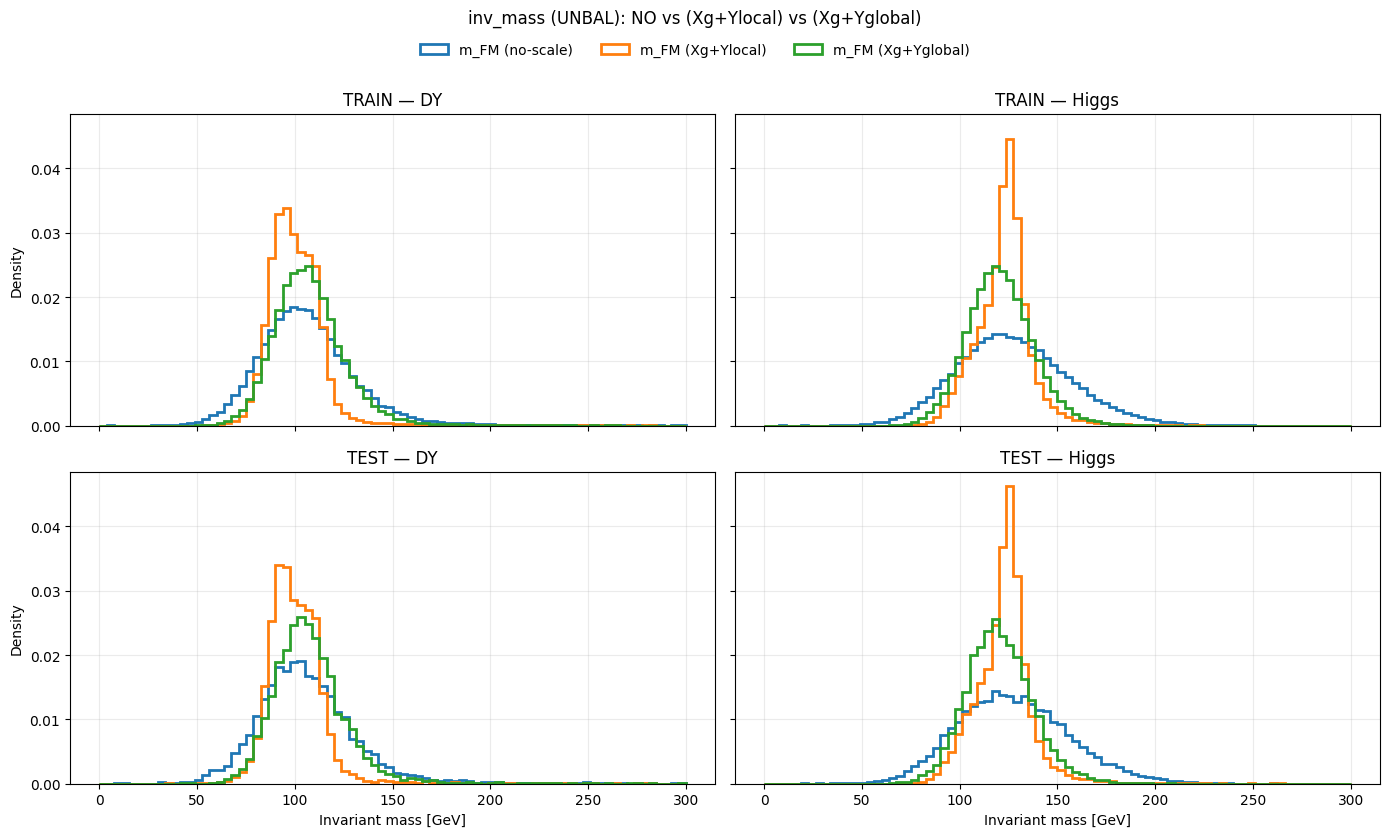

In [182]:
# ============================================================
# 6 — COMPARE 3 TRAININGS (UNBALANCED):
#     inv_mass_FM (NO vs Xg+Ylocal vs Xg+Yg)
#     2x2 grid: (TRAIN/TEST) x (DY/Higgs)
# ============================================================

# ------------------------------------------------------------
#  make inference more reproducible
# ------------------------------------------------------------
SEED_PRED = 42
np.random.seed(SEED_PRED)
torch.manual_seed(SEED_PRED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_PRED)

# ------------------------------------------------------------
# Base splits (common events for fair comparison)
# ------------------------------------------------------------
df_train_base, df_val_base, df_test_base = res["df_splits"]

def masks_01(df, class_col="class"):
    c = df[class_col].to_numpy()
    return (c == 0), (c == 1)

# ------------------------------------------------------------
# 1) Predictions on the SAME df_train_base / df_test_base
# ------------------------------------------------------------
# --- NO scaling ---
df_pred_tr_nos = predict_tau_corr_general(
    df_train_base, res, res["train_cols"], res["y_cols"], n_steps=60, batch_size=8192
)
df_pred_te_nos = predict_tau_corr_general(
    df_test_base,  res, res["train_cols"], res["y_cols"], n_steps=60, batch_size=8192
)

# --- X global + Y local ---
df_pred_tr_loc = predict_tau_corr_general_scaled_mixed(
    df_train_base, res_scaled, res_scaled["train_cols"], res_scaled["y_cols"], n_steps=60, batch_size=8192
)
df_pred_te_loc = predict_tau_corr_general_scaled_mixed(
    df_test_base,  res_scaled, res_scaled["train_cols"], res_scaled["y_cols"], n_steps=60, batch_size=8192
)

# --- X global + Y global ---
df_pred_tr_glo = predict_tau_corr_general_scaled_global(
    df_train_base, res_global, res_global["train_cols"], res_global["y_cols"], n_steps=60, batch_size=8192
)
df_pred_te_glo = predict_tau_corr_general_scaled_global(
    df_test_base,  res_global, res_global["train_cols"], res_global["y_cols"], n_steps=60, batch_size=8192
)

# ------------------------------------------------------------
# 2) Add FM masses (3 variants) on SAME base dfs
# ------------------------------------------------------------
COMMON_KW = dict(
    pt1_col="tau1_pt_reco_corrPNet", pt2_col="tau2_pt_reco_corrPNet",
    eta1_col="tau1_eta", phi1_col="tau1_phi", m1_col="tau1_mass",
    eta2_col="tau2_eta", phi2_col="tau2_phi", m2_col="tau2_mass",
    clip_corr=(0.0, 5.0),
)

df_train_nos = add_fm_mass_columns(df_train_base.copy(), df_pred_tr_nos,
                                  out_mass_col="inv_mass_FM_noscale", **COMMON_KW)
df_test_nos  = add_fm_mass_columns(df_test_base.copy(),  df_pred_te_nos,
                                  out_mass_col="inv_mass_FM_noscale", **COMMON_KW)

df_train_loc = add_fm_mass_columns(df_train_base.copy(), df_pred_tr_loc,
                                  out_mass_col="inv_mass_FM_xg_ylocal", **COMMON_KW)
df_test_loc  = add_fm_mass_columns(df_test_base.copy(),  df_pred_te_loc,
                                  out_mass_col="inv_mass_FM_xg_ylocal", **COMMON_KW)

df_train_glo = add_fm_mass_columns(df_train_base.copy(), df_pred_tr_glo,
                                  out_mass_col="inv_mass_FM_xg_yg", **COMMON_KW)
df_test_glo  = add_fm_mass_columns(df_test_base.copy(),  df_pred_te_glo,
                                  out_mass_col="inv_mass_FM_xg_yg", **COMMON_KW)

# ------------------------------------------------------------
# 3) Plot 2x2 grid overlaying 3 curves (FM variants)
# ------------------------------------------------------------
def plot_compare3_mass_grid(
    df_tr_base, df_te_base,
    df_tr_nos, df_te_nos,
    df_tr_loc, df_te_loc,
    df_tr_glo, df_te_glo,
    class_col="class",
    fm_nos="inv_mass_FM_noscale",
    fm_loc="inv_mass_FM_xg_ylocal",
    fm_glo="inv_mass_FM_xg_yg",
    bins=80,
    m_range=(0, 300),
    density=True,
    suptitle="inv_mass: NO vs (Xg+Ylocal) vs (Xg+Yglobal)",
):
    m_dy_tr, m_h_tr = masks_01(df_tr_base, class_col=class_col)
    m_dy_te, m_h_te = masks_01(df_te_base, class_col=class_col)

    fig, axs = plt.subplots(2, 2, figsize=(14, 8.5), sharex=True, sharey=True)
    fig.suptitle(suptitle)

    panels = [
        ("TRAIN — DY",    m_dy_tr, df_tr_nos, df_tr_loc, df_tr_glo, axs[0, 0]),
        ("TRAIN — Higgs", m_h_tr,  df_tr_nos, df_tr_loc, df_tr_glo, axs[0, 1]),
        ("TEST — DY",     m_dy_te, df_te_nos, df_te_loc, df_te_glo, axs[1, 0]),
        ("TEST — Higgs",  m_h_te,  df_te_nos, df_te_loc, df_te_glo, axs[1, 1]),
    ]

    for title, mask, dfn, dfl, dfg, ax in panels:
        mn = dfn.loc[mask, fm_nos].to_numpy()
        ml = dfl.loc[mask, fm_loc].to_numpy()
        mg = dfg.loc[mask, fm_glo].to_numpy()

        mn = mn[np.isfinite(mn)]
        ml = ml[np.isfinite(ml)]
        mg = mg[np.isfinite(mg)]

        ax.hist(mn, bins=bins, range=m_range, histtype="step", density=density, linewidth=2, label="m_FM (no-scale)")
        ax.hist(ml, bins=bins, range=m_range, histtype="step", density=density, linewidth=2, label="m_FM (Xg+Ylocal)")
        ax.hist(mg, bins=bins, range=m_range, histtype="step", density=density, linewidth=2, label="m_FM (Xg+Yglobal)")
        ax.set_title(title)
        ax.grid(True, alpha=0.25)

    for ax in axs[1, :]:
        ax.set_xlabel("Invariant mass [GeV]")
    for ax in axs[:, 0]:
        ax.set_ylabel("Density" if density else "Counts")

    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.955))
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    return fig

fig_cmp3 = plot_compare3_mass_grid(
    df_tr_base=df_train_base, df_te_base=df_test_base,
    df_tr_nos=df_train_nos, df_te_nos=df_test_nos,
    df_tr_loc=df_train_loc, df_te_loc=df_test_loc,
    df_tr_glo=df_train_glo, df_te_glo=df_test_glo,
    m_range=(0, 300),
    bins=80,
    density=True,
    suptitle="inv_mass (UNBAL): NO vs (Xg+Ylocal) vs (Xg+Yglobal)",
)
plt.show()


In [179]:
# ============================================================
# S/B in fixed window [110,130] GeV for FM masses
# Signal = Higgs, Background = DY
# Computes S, B, S/B, S/sqrt(B) for TRAIN and TEST
# ============================================================
def masks_01(df, class_col="class"):
    vals = df[class_col].to_numpy()
    m_dy = (vals == 0)
    m_h  = (vals == 1)
    if not np.all(m_dy | m_h):
        bad = np.unique(vals[~(m_dy | m_h)])
        raise ValueError(f"Found unexpected class labels in '{class_col}': {bad}")
    return m_dy, m_h

def sb_in_window(df_mass, mass_col, w=(110.0, 130.0), class_col="class"):
    lo, hi = map(float, w)

    m_dy, m_h = masks_01(df_mass, class_col=class_col)

    mass = df_mass[mass_col].to_numpy(dtype=float)
    ok = np.isfinite(mass)
    in_win = ok & (mass >= lo) & (mass <= hi)

    S = int(np.sum(in_win & m_h))
    B = int(np.sum(in_win & m_dy))

    S_tot = int(np.sum(ok & m_h))
    B_tot = int(np.sum(ok & m_dy))

    sb = (S / B) if B > 0 else np.inf
    s_sqrtb = (S / np.sqrt(B)) if B > 0 else np.inf

    frac_S = (S / S_tot) if S_tot > 0 else np.nan
    frac_B = (B / B_tot) if B_tot > 0 else np.nan

    return {
        "mass_col": mass_col,
        "window": f"[{lo:.0f},{hi:.0f}]",
        "S": S,
        "B": B,
        "S/B": sb,
        "S/sqrt(B)": s_sqrtb,
        "S_inwin/S_tot": frac_S,
        "B_inwin/B_tot": frac_B,
        "S_tot": S_tot,
        "B_tot": B_tot,
    }

def sb_table(train_dfs, test_dfs, mass_cols, labels, w=(110,130), class_col="class"):
    rows = []
    for df_tr, df_te, mc, lab in zip(train_dfs, test_dfs, mass_cols, labels):
        r_tr = sb_in_window(df_tr, mc, w=w, class_col=class_col)
        r_tr["split"] = "TRAIN"
        r_tr["label"] = lab
        rows.append(r_tr)

        r_te = sb_in_window(df_te, mc, w=w, class_col=class_col)
        r_te["split"] = "TEST"
        r_te["label"] = lab
        rows.append(r_te)

    out = pd.DataFrame(rows)
    out = out[["split","label","mass_col","window","S","B","S/B","S/sqrt(B)",
               "S_inwin/S_tot","B_inwin/B_tot","S_tot","B_tot"]]
    return out

# usage
train_dfs = [df_train_nos, df_train_loc, df_train_glo]
test_dfs  = [df_test_nos,  df_test_loc,  df_test_glo]
mass_cols = ["inv_mass_FM_noscale", "inv_mass_FM_xg_ylocal", "inv_mass_FM_xg_yg"]
labels    = ["FM no-scale", "FM Xg+Ylocal", "FM Xg+Yglobal"]

df_sb = sb_table(train_dfs, test_dfs, mass_cols, labels, w=(110,130), class_col="class")

# prettier numeric formatting 
df_sb_disp = df_sb.copy()
for c in ["S/B","S/sqrt(B)","S_inwin/S_tot","B_inwin/B_tot"]:
    df_sb_disp[c] = df_sb_disp[c].astype(float)

display(df_sb_disp)


,split,label,mass_col,window,S,B,S/B,S/sqrt(B),S_inwin/S_tot,B_inwin/B_tot,S_tot,B_tot
0,TRAIN,FM no-scale,inv_mass_FM_noscale,"[110,130]",28331,10118,2.800059,281.653120,0.276856,0.245368,102331,41236
1,TEST,FM no-scale,inv_mass_FM_noscale,"[110,130]",3545,1307,2.712318,98.056965,0.277061,0.253737,12795,5151
2,TRAIN,FM Xg+Ylocal,inv_mass_FM_xg_ylocal,"[110,130]",61013,6999,8.717388,729.296926,0.596232,0.169730,102331,41236
3,TEST,FM Xg+Ylocal,inv_mass_FM_xg_ylocal,"[110,130]",7661,870,8.805747,259.732225,0.598750,0.168899,12795,5151
4,TRAIN,FM Xg+Yglobal,inv_mass_FM_xg_yg,"[110,130]",47370,12146,3.900049,429.820125,0.462910,0.294548,102331,41236
5,TEST,FM Xg+Yglobal,inv_mass_FM_xg_yg,"[110,130]",5993,1503,3.987359,154.584088,0.468386,0.291788,12795,5151


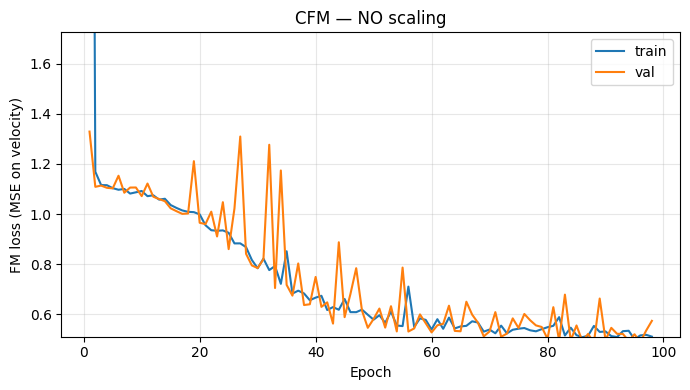

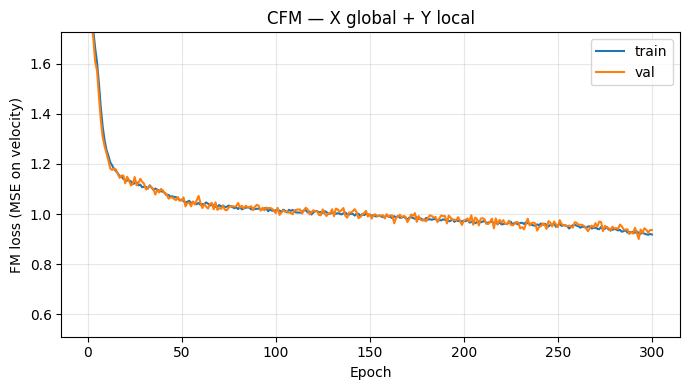

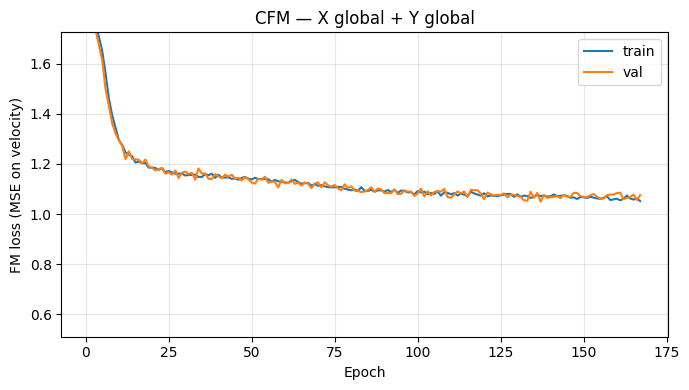

In [180]:
# ============================================================
# 7 — LOSS CURVES: three trainings (separate plots)
# ============================================================
def plot_loss(res, title, ylim=None, logy=False):
    tr = res["loss_history"]["train"]
    va = res["loss_history"]["val"]

    e_tr = np.arange(1, len(tr) + 1)
    e_va = np.arange(1, len(va) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(e_tr, tr, label="train")
    plt.plot(e_va, va, label="val")
    plt.xlabel("Epoch")
    plt.ylabel("FM loss (MSE on velocity)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()

    if ylim is not None:
        plt.ylim(*ylim)
    if logy:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()


# --- choose common y-limits for fair visual comparison (optional) ---
all_losses = (
    res["loss_history"]["train"] + res["loss_history"]["val"] +
    res_scaled["loss_history"]["train"] + res_scaled["loss_history"]["val"] +
    res_global["loss_history"]["train"] + res_global["loss_history"]["val"]
)
all_losses = np.asarray(all_losses, dtype=float)
all_losses = all_losses[np.isfinite(all_losses) & (all_losses > 0)]
ylim_common = (float(np.percentile(all_losses, 1)), float(np.percentile(all_losses, 99))) if all_losses.size else None

# --- 1) NO scaling ---
plot_loss(res, title="CFM — NO scaling", ylim=ylim_common, logy=False)

# --- 2) X global + Y local ---
plot_loss(res_scaled, title="CFM — X global + Y local", ylim=ylim_common, logy=False)

# --- 3) X global + Y global ---
plot_loss(res_global, title="CFM — X global + Y global", ylim=ylim_common, logy=False)


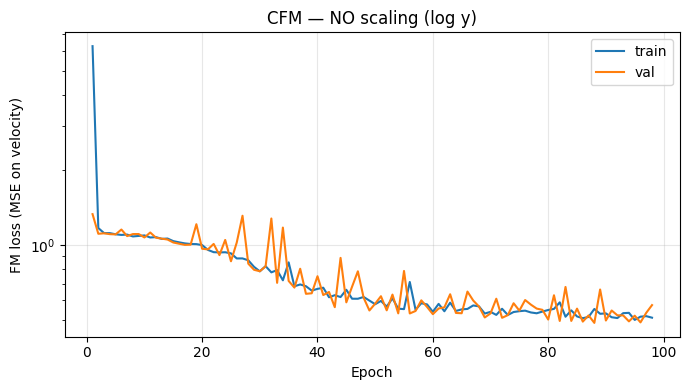

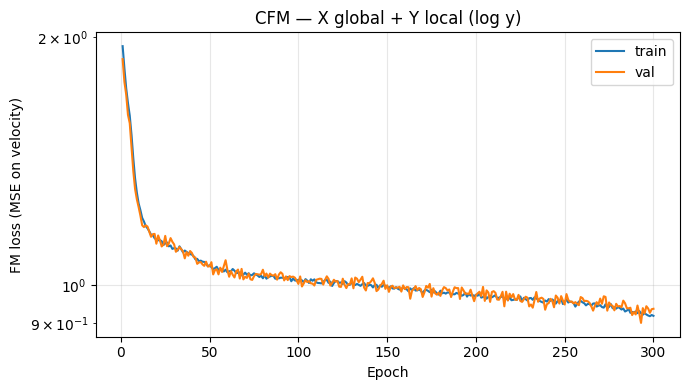

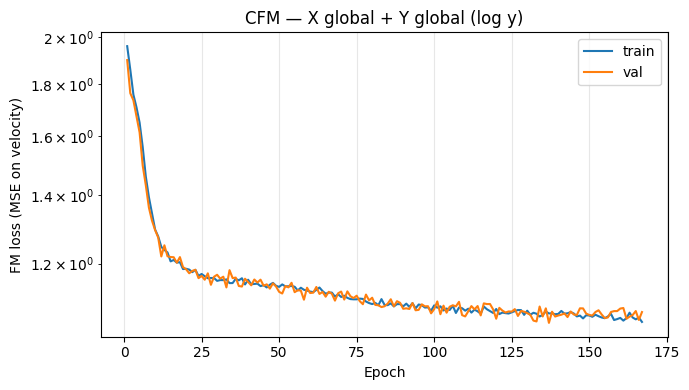

In [181]:
plot_loss(res,        "CFM — NO scaling (log y)",        ylim=None, logy=True)
plot_loss(res_scaled, "CFM — X global + Y local (log y)", ylim=None, logy=True)
plot_loss(res_global, "CFM — X global + Y global (log y)",ylim=None, logy=True)


# Plot Variabili Post-Scaling

---

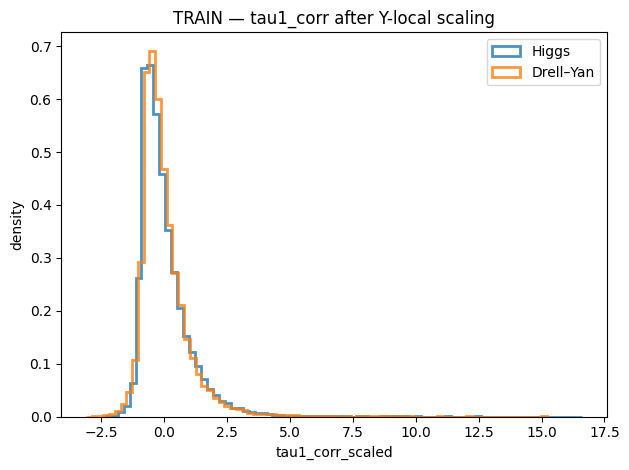

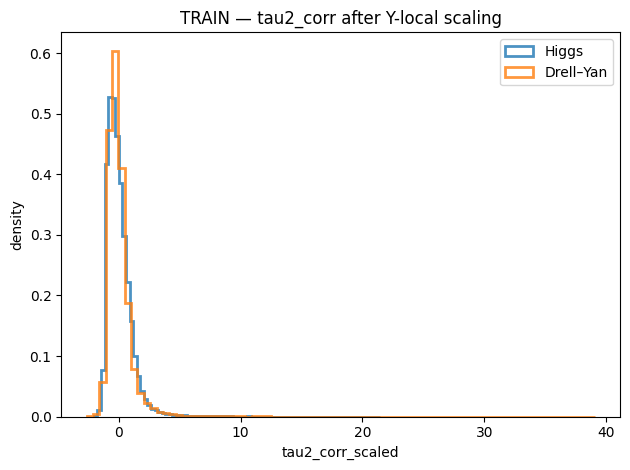

[train] mean/std Higgs: [-2.6827582e-09  8.5108196e-09] [1.000012 1.000012]
[train] mean/std DY   : [-2.2202138e-09  3.3303207e-09] [1.000012 1.000012]


In [89]:
# Plot delle variabili target post-scaling (local): 

# ============================================================
# Plot targets AFTER scaling (use saved scalers from res dict)
# DY: class==0, Higgs: class==1
# ============================================================

def plot_targets_after_saved_scaling(res, which_split="train", bins=80, use_hexbin=True):
    """
    res: dict like res_tb_scaled_mixed, containing:
      - res["scalers"] with y_scaler_dy, y_scaler_h (for Y-local case)
      - res["df_splits"] = (df_train, df_val, df_test)
      - res["y_cols"] (i.e. ["tau1_corr","tau2_corr"])
    which_split: "train" | "val" | "test"
    """

    df_train, df_val, df_test = res["df_splits"]
    df = {"train": df_train, "val": df_val, "test": df_test}[which_split].copy()

    y_cols = res["y_cols"]
    assert len(y_cols) == 2, "Mi aspetto 2 target (tau1_corr, tau2_corr)."
    y1, y2 = y_cols

    scalers = res["scalers"]

    # ---- Y-local scalers 
    if "y_scaler_dy" not in scalers or "y_scaler_h" not in scalers:
        raise KeyError("In res['scalers'] non trovo y_scaler_dy / y_scaler_h. "
                       "Questo res non è un Y-local oppure i nomi delle key sono diversi.")
    y_scaler_dy = scalers["y_scaler_dy"]
    y_scaler_h  = scalers["y_scaler_h"]

    # ---- masks: DY vs Higgs
    c = df["class"].to_numpy()
    m_dy = (c == 0)
    m_h  = (c == 1)

    Y = df[[y1, y2]].to_numpy(dtype=np.float32)
    Y_scaled = np.empty_like(Y, dtype=np.float32)

    if m_dy.sum() > 0:
        Y_scaled[m_dy] = y_scaler_dy.transform(Y[m_dy]).astype(np.float32)
    if m_h.sum() > 0:
        Y_scaled[m_h]  = y_scaler_h.transform(Y[m_h]).astype(np.float32)

    # add columns for convenience
    df[f"{y1}_scaled"] = Y_scaled[:, 0]
    df[f"{y2}_scaled"] = Y_scaled[:, 1]

    # -------------------------
    # 1D plots: Higgs vs DY
    # -------------------------
    for col, label in [(f"{y1}_scaled", y1), (f"{y2}_scaled", y2)]:
        plt.figure()
        plt.hist(df.loc[m_h,  col].values, bins=bins, density=True, alpha=0.8, histtype='step', lw=2, label="Higgs")
        plt.hist(df.loc[m_dy, col].values, bins=bins, density=True, alpha=0.8, histtype='step', lw=2, label="Drell–Yan")
        plt.xlabel(col)
        plt.ylabel("density")
        plt.title(f"{which_split.upper()} — {label} after Y-local scaling")
        plt.legend()
        plt.tight_layout()
        plt.show()


    # optional quick sanity numbers
    print(f"[{which_split}] mean/std Higgs:", df.loc[m_h, [f"{y1}_scaled", f"{y2}_scaled"]].mean().values,
          df.loc[m_h, [f"{y1}_scaled", f"{y2}_scaled"]].std().values)
    print(f"[{which_split}] mean/std DY   :", df.loc[m_dy, [f"{y1}_scaled", f"{y2}_scaled"]].mean().values,
          df.loc[m_dy, [f"{y1}_scaled", f"{y2}_scaled"]].std().values)

    return df  # returns df with *_scaled columns


# ============================================================
# USO: caso B (X global + Y local)
# ============================================================

# TRAIN
df_tr_scaled = plot_targets_after_saved_scaling(res_tb_scaled_mixed, which_split="train")

# se voglio anche VAL / TEST uso così :
# df_va_scaled = plot_targets_after_saved_scaling(res_tb_scaled_mixed, which_split="val")
# df_te_scaled = plot_targets_after_saved_scaling(res_tb_scaled_mixed, which_split="test")


In [91]:
# Verifico media  0 e varianza  1
df_tr_scaled.groupby("class")[["tau1_corr_scaled","tau2_corr_scaled"]].agg(["mean","std"])

tau1_corr_scaled           tau2_corr_scaled          
                  mean       std             mean       std
class                                                      
0        -1.519170e-09  1.000012     3.075921e-09  1.000012
1        -2.141256e-09  1.000012     8.570805e-09  1.000012

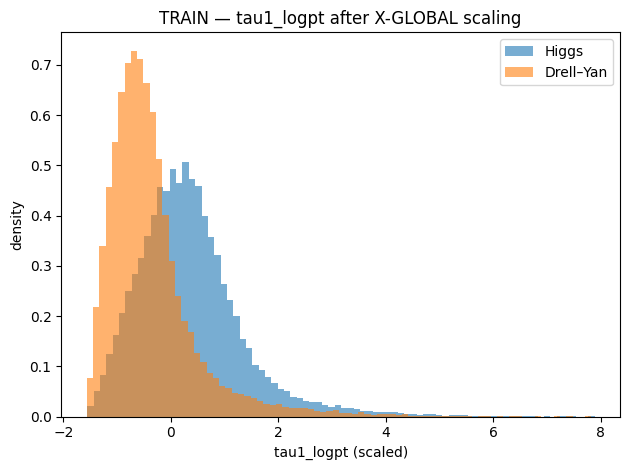

TRAIN — tau1_logpt (scaled)  |  Higgs mean/std: +0.3623 / 1.0060   DY mean/std: -0.3623 / 0.8517


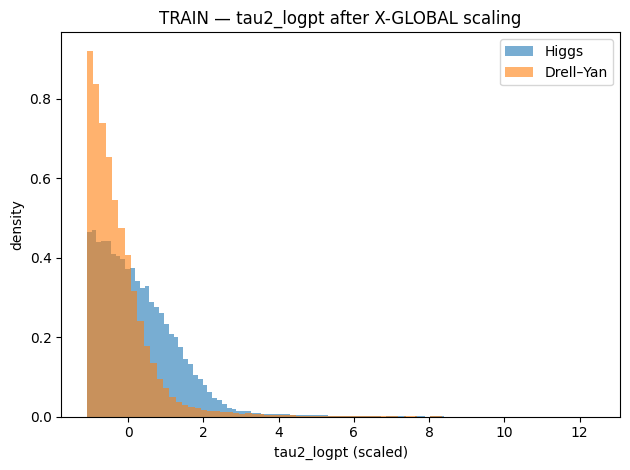

TRAIN — tau2_logpt (scaled)  |  Higgs mean/std: +0.2668 / 1.0669   DY mean/std: -0.2668 / 0.8482


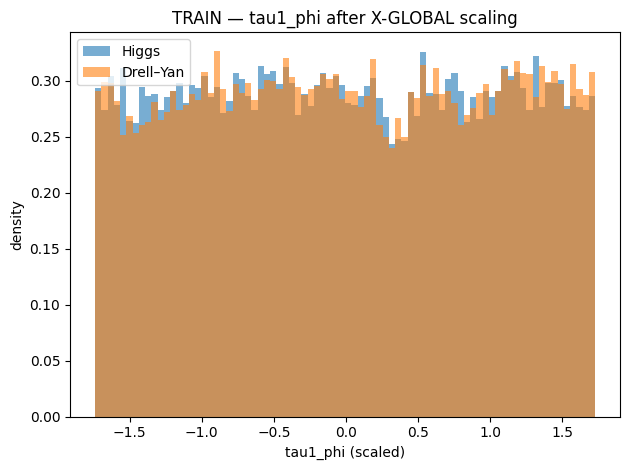

TRAIN — tau1_phi (scaled)  |  Higgs mean/std: -0.0080 / 0.9999   DY mean/std: +0.0080 / 1.0001


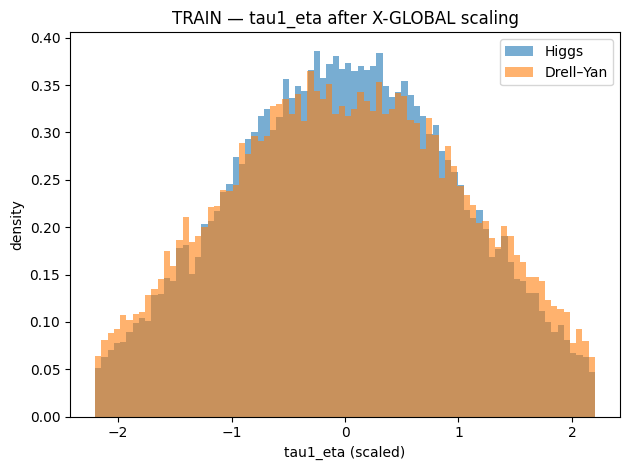

TRAIN — tau1_eta (scaled)  |  Higgs mean/std: -0.0020 / 0.9732   DY mean/std: +0.0020 / 1.0261


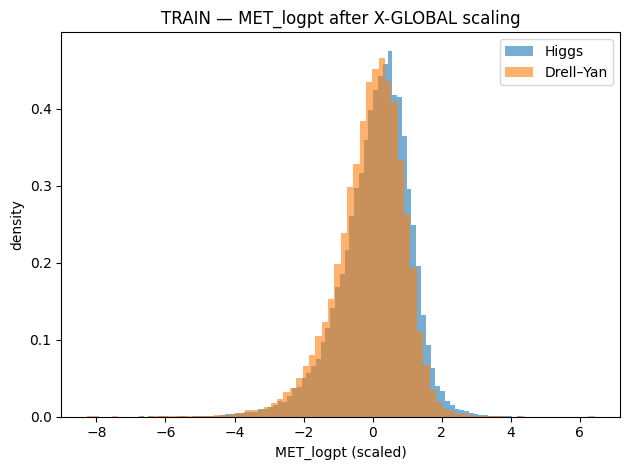

TRAIN — MET_logpt (scaled)  |  Higgs mean/std: +0.0858 / 1.0101   DY mean/std: -0.0858 / 0.9824


In [96]:
# Plot context post-scaling, global vs local

# ============================================================
# Plot context variables AFTER X-global scaling (no X-local available)
# Uses saved x_scaler inside res dict (e.g. res_tb_scaled_mixed)
# ============================================================

def plot_context_after_Xglobal_scaling(res, vars_to_plot, which_split="train", bins=80):
    """
    res must contain:
      - res["scalers"]["x_scaler"]  (StandardScaler fitted on TRAIN)
      - res["df_splits"] = (df_train, df_val, df_test)
      - res["train_cols"] list of context feature names (must include vars_to_plot)
    """
    df_train, df_val, df_test = res["df_splits"]
    df = {"train": df_train, "val": df_val, "test": df_test}[which_split]

    train_cols = res["train_cols"]
    x_scaler = res["scalers"]["x_scaler"]

    # transform all X once 
    X_scaled = x_scaler.transform(df[train_cols].to_numpy())

    c = df["class"].to_numpy()
    m_dy = (c == 0)  # Drell–Yan
    m_h  = (c == 1)  # Higgs

    for var in vars_to_plot:
        if var not in train_cols:
            raise ValueError(f"'{var}' non è in train_cols. Controlla il nome.")
        idx = train_cols.index(var)
        v = X_scaled[:, idx]

        plt.figure()
        plt.hist(v[m_h],  bins=bins, density=True, alpha=0.6, label="Higgs")
        plt.hist(v[m_dy], bins=bins, density=True, alpha=0.6, label="Drell–Yan")
        plt.xlabel(f"{var} (scaled)")
        plt.ylabel("density")
        plt.title(f"{which_split.upper()} — {var} after X-GLOBAL scaling")
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f"{which_split.upper()} — {var} (scaled)  |  Higgs mean/std: {v[m_h].mean():+.4f} / {v[m_h].std():.4f}   "
              f"DY mean/std: {v[m_dy].mean():+.4f} / {v[m_dy].std():.4f}")

# ============================================================
# USO
# ============================================================

vars_emblematiche = [
    "tau1_logpt",
    "tau2_logpt",
    "tau1_phi",
    "tau1_eta",
    "MET_logpt",              
]

plot_context_after_Xglobal_scaling(res_tb_scaled_mixed, vars_emblematiche, which_split="train")
# se serve anche:
# plot_context_after_Xglobal_scaling(res_tb_scaled_mixed, vars_emblematiche, which_split="test")



# 1) Balanced vs Unbalanced

In [118]:
# 0 BUILD A BALANCED DF

def make_balanced_df_dy_higgs(df, class_col="class", seed=42, verbose=True):
    df = df.copy()
    df_dy = df[df[class_col] == 0]  
    df_h  = df[df[class_col] == 1]  
    n = min(len(df_dy), len(df_h))

    df_dy_s = df_dy.sample(n=n, random_state=seed, replace=False)
    df_h_s  = df_h.sample(n=n, random_state=seed, replace=False)

    df_bal = pd.concat([df_dy_s, df_h_s], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    if verbose:
        print("WHOLE (balanced) fractions:")
        print(df_bal[class_col].value_counts(normalize=True))
        print("Counts:")
        print(df_bal[class_col].value_counts())

    return df_bal


def split_80_10_10_stratified(df, class_col="class", seed=42):
    df_tr, df_tmp = train_test_split(
        df, test_size=0.20, random_state=seed, shuffle=True, stratify=df[class_col]
    )
    df_va, df_te = train_test_split(
        df_tmp, test_size=0.50, random_state=seed, shuffle=True, stratify=df_tmp[class_col]
    )
    return df_tr.reset_index(drop=True), df_va.reset_index(drop=True), df_te.reset_index(drop=True)


# ---- build balanced whole dataset
df_all_balanced = make_balanced_df_dy_higgs(df_all, class_col="class", seed=42, verbose=True)

# ---- split FROM the balanced dataset
df_train, df_val, df_test = split_80_10_10_stratified(df_all_balanced, class_col="class", seed=42)

print("\nTRAIN fractions:\n", df_train["class"].value_counts(normalize=True))
print("\nVAL fractions:\n",   df_val["class"].value_counts(normalize=True))
print("\nTEST fractions:\n",  df_test["class"].value_counts(normalize=True))

WHOLE (balanced) fractions:
class
0    0.5
1    0.5
Name: proportion, dtype: float64
Counts:
class
0    51425
1    51425
Name: count, dtype: int64

TRAIN fractions:
 class
0    0.5
1    0.5
Name: proportion, dtype: float64

VAL fractions:
 class
1    0.500049
0    0.499951
Name: proportion, dtype: float64

TEST fractions:
 class
0    0.500049
1    0.499951
Name: proportion, dtype: float64


In [119]:
def run_training(tag, prepare_fn, df_train, df_val, df_test, train_cols, y_cols,
                 prepare_kwargs=None, batch_size=1024, lr=2e-4, epochs=300,
                 patience=30, min_delta=1e-4):

    prepare_kwargs = prepare_kwargs or {}

    # prepare arrays
    Xtr, Xva, Xte, ytr, yva, yte, scalers = prepare_fn(
        df_train, df_val, df_test,
        train_cols=train_cols,
        y_cols=y_cols,
        **prepare_kwargs
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    dl_tr = DataLoader(TabularFMDataset(Xtr, ytr), batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    dl_va = DataLoader(TabularFMDataset(Xva, yva), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    model = ConditionalVelocityField(
        x_dim=ytr.shape[1],
        context_dim=Xtr.shape[1],
        hidden=(256,256,256),
        time_embed_dim=64,
        dropout=0.0,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    hist_tr, hist_va = [], []

    for ep in range(1, epochs + 1):
        model.train()
        tr_losses = []
        for xb, yb in dl_tr:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            loss = fm_loss(model, xb, yb, device=device)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())
        tr_loss = float(np.mean(tr_losses))

        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in dl_va:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                loss = fm_loss(model, xb, yb, device=device)
                va_losses.append(loss.item())
        va_loss = float(np.mean(va_losses))

        hist_tr.append(tr_loss)
        hist_va.append(va_loss)

        if ep % 20 == 0 or ep == 1:
            print(f"[{tag} | ep {ep:03d}/{epochs}] train={tr_loss:.6f}  val={va_loss:.6f}")

        if stopper.step(va_loss, model):
            print(f"[{tag}] Early stopping at epoch {ep} (best val={stopper.best:.6f})")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    res = {
        "model": model,
        "device": device,
        "scalers": scalers if scalers is not None else {"mode": "NO_SCALING"},
        "df_splits": (df_train, df_val, df_test),
        "loss_history": {"train": hist_tr, "val": hist_va},
        "train_cols": train_cols,
        "y_cols": y_cols,
        "tag": tag,
    }
    return res


# ============================================================
# RUN A/B/C on BALANCED splits
# ============================================================

# A: NO scaling
res_bal_noscale = run_training(
    tag="A NO-scale (all balanced)",
    prepare_fn=prepare_arrays_noscale,
    df_train=df_train, df_val=df_val, df_test=df_test,
    train_cols=train_cols, y_cols=y_cols,
)

# B: X global + Y local
res_bal_scaled_mixed = run_training(
    tag="B Xg+Ylocal (all balanced)",
    prepare_fn=prepare_arrays_scaled_mixed,
    df_train=df_train, df_val=df_val, df_test=df_test,
    train_cols=train_cols, y_cols=y_cols,
    prepare_kwargs={"class_col": "class"},
)

# C: X global + Y global
res_bal_global = run_training(
    tag="C Xg+Yg (all balanced)",
    prepare_fn=prepare_arrays_scaled_global,
    df_train=df_train, df_val=df_val, df_test=df_test,
    train_cols=train_cols, y_cols=y_cols,
)


[A NO-scale (all balanced) | ep 001/300] train=1.618821  val=1.132905
[A NO-scale (all balanced) | ep 020/300] train=0.624231  val=0.615193
[A NO-scale (all balanced) | ep 040/300] train=0.518348  val=0.512061
[A NO-scale (all balanced) | ep 060/300] train=0.498255  val=0.536161
[A NO-scale (all balanced) | ep 080/300] train=0.482546  val=0.481832
[A NO-scale (all balanced) | ep 100/300] train=0.466383  val=0.463109
[A NO-scale (all balanced)] Early stopping at epoch 112 (best val=0.438838)
[B Xg+Ylocal (all balanced) | ep 001/300] train=1.935333  val=1.852038
[B Xg+Ylocal (all balanced) | ep 020/300] train=1.135091  val=1.144480
[B Xg+Ylocal (all balanced) | ep 040/300] train=1.104123  val=1.103648
[B Xg+Ylocal (all balanced) | ep 060/300] train=1.064925  val=1.058848
[B Xg+Ylocal (all balanced) | ep 080/300] train=1.033538  val=1.016269
[B Xg+Ylocal (all balanced) | ep 100/300] train=1.030779  val=1.114318
[B Xg+Ylocal (all balanced) | ep 120/300] train=1.022294  val=1.043286
[B Xg+Y

In [120]:
# Devo aggiungere gli iperparametri per salvare correttamente :
def patch_res_for_save(res, seed=42,
                       batch_size=1024,
                       lr=2e-4,
                       epochs=300,
                       patience=30,
                       min_delta=1e-4):

    res["seed"] = seed

    res["hyperparams"] = {
        "batch_size": batch_size,
        "lr": lr,
        "epochs": epochs,
        "patience": patience,
        "min_delta": min_delta,
        "hidden": (256, 256, 256),
        "time_embed_dim": 64,
        "dropout": 0.0,
    }

    return res


patch_res_for_save(res_bal_noscale)
patch_res_for_save(res_bal_scaled_mixed)
patch_res_for_save(res_bal_global)

{'model': ConditionalVelocityField(
   (time_embed): FourierTimeEmbedding()
   (net): Sequential(
     (0): Linear(in_features=118, out_features=256, bias=True)
     (1): SiLU()
     (2): Linear(in_features=256, out_features=256, bias=True)
     (3): SiLU()
     (4): Linear(in_features=256, out_features=256, bias=True)
     (5): SiLU()
     (6): Linear(in_features=256, out_features=2, bias=True)
   )
 ),
 'device': 'cpu',
 'scalers': {'mode': 'X_GLOBAL__Y_GLOBAL',
  'x_scaler': StandardScaler(),
  'y_scaler': StandardScaler(),
  'train_cols': ['tau1_logpt',
   'tau1_eta',
   'tau1_phi',
   'tau1_mass',
   'tau1_dxy',
   'tau1_dz',
   'tau1_ptCorrPNet',
   'tau1_rawPNetVSjet',
   'tau1_rawDeepTau2018v2p5VSjet',
   'tau1_charge',
   'tau1_dM_0',
   'tau1_dM_1',
   'tau1_dM_2',
   'tau1_dM_10',
   'tau1_dM_11',
   'tau1_leadTkDeltaEta',
   'tau1_leadTkDeltaPhi',
   'tau1_leadTkPtOverTauPt',
   'tau2_logpt',
   'tau2_eta',
   'tau2_phi',
   'tau2_mass',
   'tau2_dxy',
   'tau2_dz',
   'tau

In [121]:
save_full_run(res_bal_noscale,      folder="results/noscale_balanced")
save_full_run(res_bal_scaled_mixed, folder="results/mixedscale_balanced")
save_full_run(res_bal_global,       folder="results/scaled_balanced")



 Run salvato correttamente in: results/noscale_balanced


 Run salvato correttamente in: results/mixedscale_balanced


 Run salvato correttamente in: results/scaled_balanced



In [190]:
# ------------------------------------------------------------
# 1) Predictions on BALANCED TEST for the 3 trainings
# ------------------------------------------------------------
df_train_b, df_val_b, df_test_b = res_bal_noscale["df_splits"]

df_pred_b_nos   = predict_tau_corr_general(df_test_b, res_bal_noscale, train_cols, y_cols, n_steps=60, batch_size=8192)
df_pred_b_mix   = predict_tau_corr_general_scaled_mixed(df_test_b, res_bal_scaled_mixed, train_cols, y_cols, n_steps=60, batch_size=8192)
df_pred_b_glob  = predict_tau_corr_general_scaled_global(df_test_b, res_bal_global, train_cols, y_cols, n_steps=60, batch_size=8192)

# add FM masses
df_b_nos  = add_fm_mass_columns(df_test_b.copy(), df_pred_b_nos,  out_mass_col="inv_mass_FM")
df_b_mix  = add_fm_mass_columns(df_test_b.copy(), df_pred_b_mix,  out_mass_col="inv_mass_FM")
df_b_glob = add_fm_mass_columns(df_test_b.copy(), df_pred_b_glob, out_mass_col="inv_mass_FM")

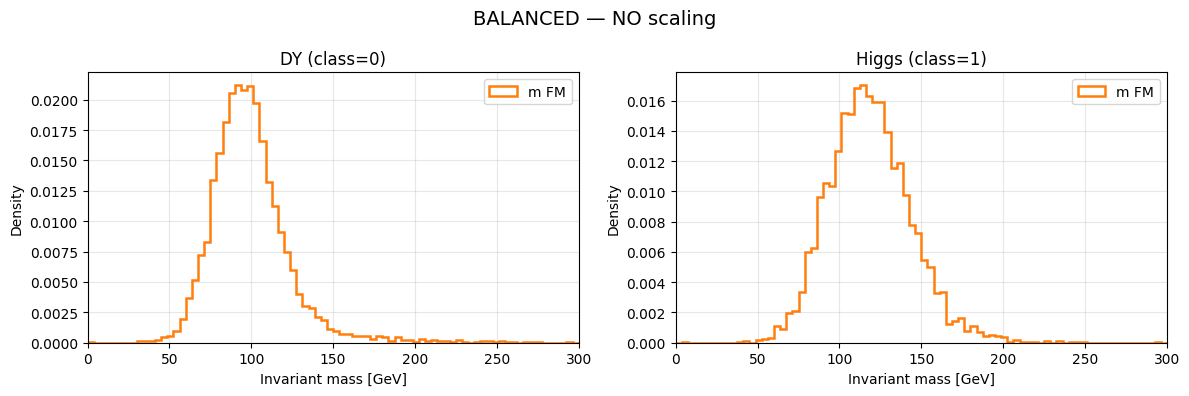

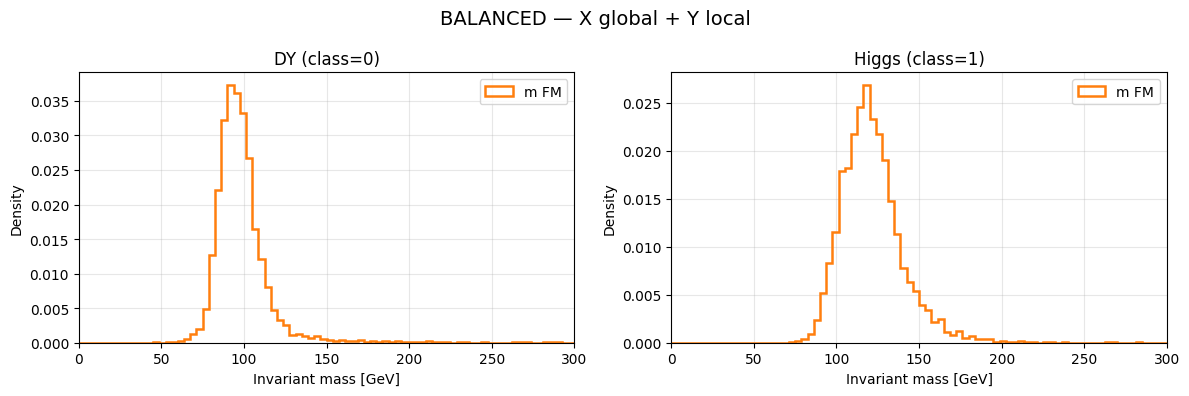

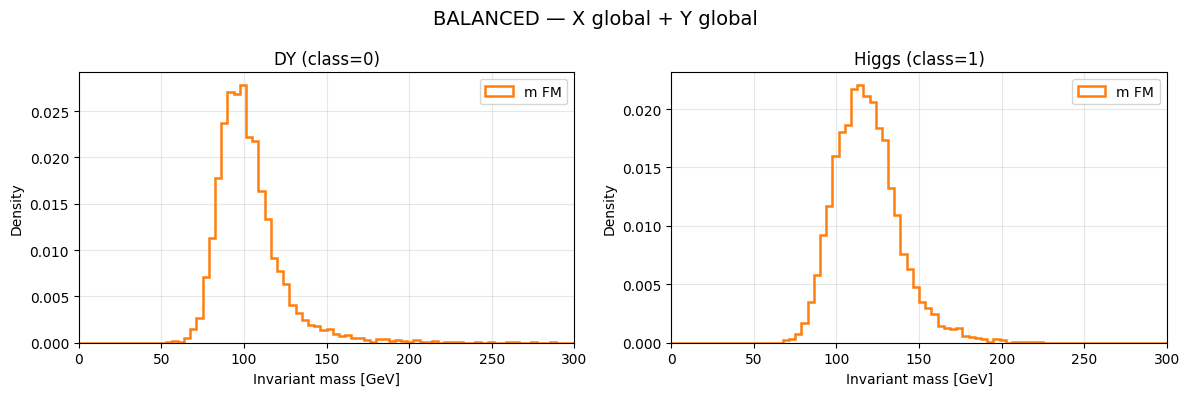

In [192]:
def plot_masses_1x2_onlyFM(df, title, bins=80, xlim=(0, 300)):
    mDY = (df["class"] == 0)
    mH  = (df["class"] == 1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    fig.suptitle(title, fontsize=14)

    ax[0].hist(df.loc[mDY, "inv_mass_FM"], bins=bins, range=xlim, density=True,
               histtype="step", linewidth=1.8, color="tab:orange", label="m FM")
    ax[0].set_title("DY (class=0)")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].hist(df.loc[mH, "inv_mass_FM"], bins=bins, range=xlim, density=True,
               histtype="step", linewidth=1.8, color="tab:orange", label="m FM")
    ax[1].set_title("Higgs (class=1)")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    for a in ax:
        a.set_xlim(*xlim)
        a.set_xlabel("Invariant mass [GeV]")
        a.set_ylabel("Density")

    plt.tight_layout()
    return fig

fig1 = plot_masses_1x2_onlyFM(
    df_b_nos,
    "BALANCED — NO scaling",
    bins=80,
    xlim=(0, 300)
)

fig2 = plot_masses_1x2_onlyFM(
    df_b_mix,
    "BALANCED — X global + Y local",
    bins=80,
    xlim=(0, 300)
)

fig3 = plot_masses_1x2_onlyFM(
    df_b_glob,
    "BALANCED — X global + Y global",
    bins=80,
    xlim=(0, 300)
)

plt.show()


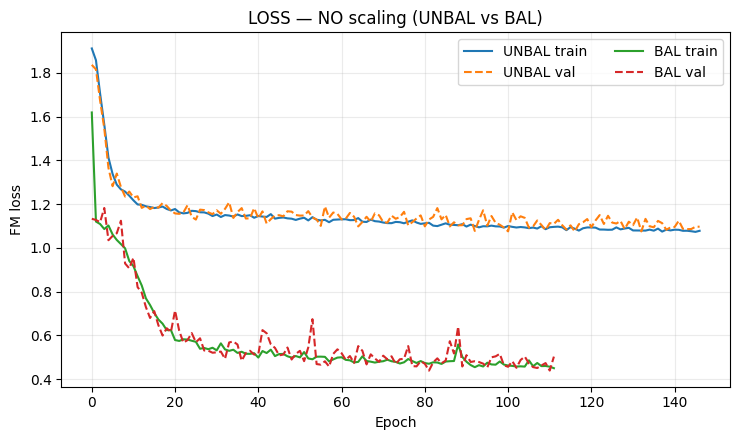

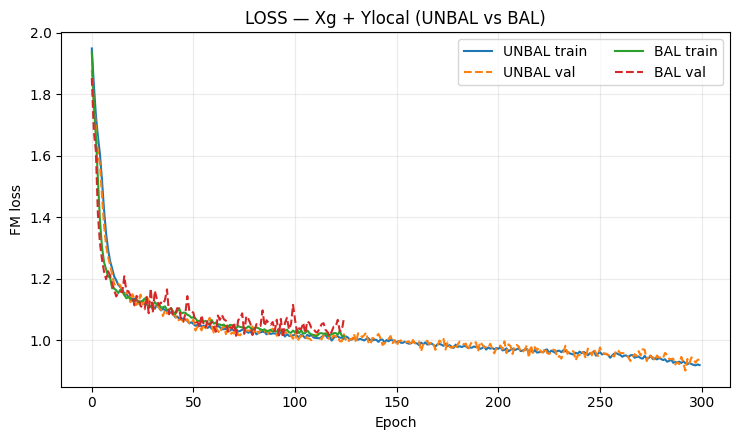

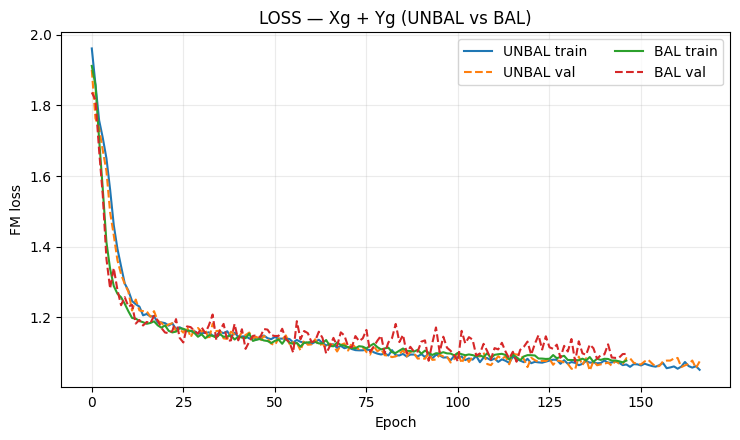

In [134]:
def plot_loss_overlay(res_unb, res_bal, title):
    tr_u = np.array(res_unb["loss_history"]["train"], dtype=float)
    va_u = np.array(res_unb["loss_history"]["val"], dtype=float)
    tr_b = np.array(res_bal["loss_history"]["train"], dtype=float)
    va_b = np.array(res_bal["loss_history"]["val"], dtype=float)

    plt.figure(figsize=(7.5,4.5))
    plt.plot(tr_u, label="UNBAL train")
    plt.plot(va_u, label="UNBAL val", linestyle="--")
    plt.plot(tr_b, label="BAL train")
    plt.plot(va_b, label="BAL val", linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("FM loss")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

# unbalanced: res (NO), res_scaled (mixed), res_global (global)
# balanced:   res_bal_noscale, res_bal_scaled_mixed, res_bal_global
plot_loss_overlay(res,        res_bal_noscale,      "LOSS — NO scaling (UNBAL vs BAL)")
plot_loss_overlay(res_scaled, res_bal_scaled_mixed, "LOSS — Xg + Ylocal (UNBAL vs BAL)")
plot_loss_overlay(res_global, res_bal_global,       "LOSS — Xg + Yg (UNBAL vs BAL)")


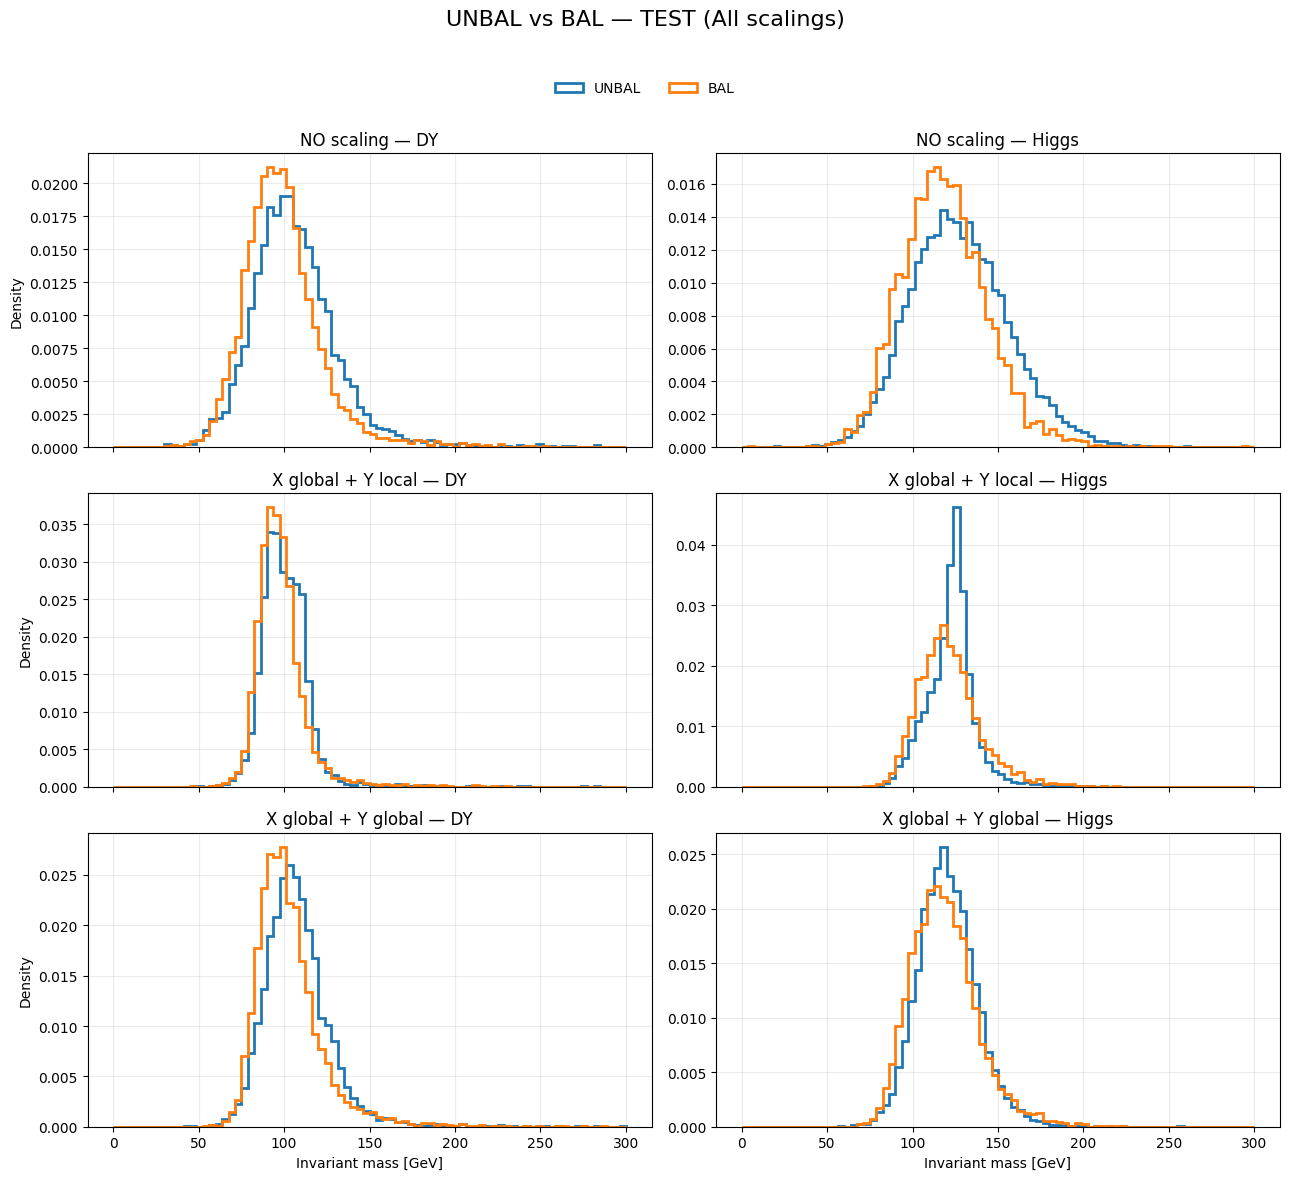

In [194]:
def plot_all_scalings_one_figure(
    df_test_nos, df_b_nos,
    df_test_loc, df_b_mix,
    df_test_glo, df_b_glob,
    bins=80, m_range=(0,300), density=True
):

    fig, ax = plt.subplots(3, 2, figsize=(13, 12), sharex=True, sharey=False)
    fig.suptitle("UNBAL vs BAL — TEST (All scalings)", fontsize=16)

    configs = [
        ("NO scaling",      df_test_nos, "inv_mass_FM_noscale",   df_b_nos,  "inv_mass_FM"),
        ("X global + Y local", df_test_loc, "inv_mass_FM_xg_ylocal", df_b_mix,  "inv_mass_FM"),
        ("X global + Y global", df_test_glo, "inv_mass_FM_xg_yg",     df_b_glob, "inv_mass_FM"),
    ]

    for row, (name, df_unb, col_unb, df_bal, col_bal) in enumerate(configs):

        mDY_u = (df_unb["class"] == 0)
        mH_u  = (df_unb["class"] == 1)
        mDY_b = (df_bal["class"] == 0)
        mH_b  = (df_bal["class"] == 1)

        # ---------------- DY ----------------
        xu = df_unb.loc[mDY_u, col_unb].to_numpy()
        xb = df_bal.loc[mDY_b, col_bal].to_numpy()
        xu = xu[np.isfinite(xu)]
        xb = xb[np.isfinite(xb)]

        ax[row, 0].hist(xu, bins=bins, range=m_range,
                        histtype="step", density=density, linewidth=2, label="UNBAL")
        ax[row, 0].hist(xb, bins=bins, range=m_range,
                        histtype="step", density=density, linewidth=density and 2 or 2, label="BAL")
        ax[row, 0].set_title(f"{name} — DY")
        ax[row, 0].grid(True, alpha=0.25)

        # ---------------- Higgs ----------------
        xu = df_unb.loc[mH_u, col_unb].to_numpy()
        xb = df_bal.loc[mH_b, col_bal].to_numpy()
        xu = xu[np.isfinite(xu)]
        xb = xb[np.isfinite(xb)]

        ax[row, 1].hist(xu, bins=bins, range=m_range,
                        histtype="step", density=density, linewidth=2, label="UNBAL")
        ax[row, 1].hist(xb, bins=bins, range=m_range,
                        histtype="step", density=density, linewidth=2, label="BAL")
        ax[row, 1].set_title(f"{name} — Higgs")
        ax[row, 1].grid(True, alpha=0.25)

    # Axis labels
    for a in ax[-1, :]:
        a.set_xlabel("Invariant mass [GeV]")
    for a in ax[:, 0]:
        a.set_ylabel("Density" if density else "Counts")

    handles, labels = ax[0, 0].get_legend_handles_labels()

    fig.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),  
        ncol=2,
        frameon=False
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.92])  

    return fig


fig_all = plot_all_scalings_one_figure(
    df_test_nos, df_b_nos,
    df_test_loc, df_b_mix,
    df_test_glo, df_b_glob,
    bins=80,
    m_range=(0,300),
    density=True
)

plt.savefig("invmass_comparison_balancedvsunbalanced.png", dpi = 300)
plt.show()


# 2) Flat Samples

In [196]:
# --------- Apro i samples flat  ------------
VBF = np.load("VBFtoXto2Tau_M-30to300.npz")

print(VBF.files)

# check :
print("x_taus:", VBF["x_taus"].shape)
print("x_taus_gen", VBF["x_gen"].shape)
print("x_met :", VBF["x_met"].shape)
print("x_jets:", VBF["x_jets"].shape)
print("m_gen :", VBF["m_gen"].shape)

['x_taus', 'x_tauprod', 'x_met', 'x_jets', 'x_neutrinos', 'x_gen', 'm_vis', 'm_vis_ptcorr', 'm_gen', 'm_gen_pt_vis_angles', 'm_vis_ptcorr_plus_nu', 'm_tauprod_nu', 'm_vis_nu_vis', 'm_fastmtt']
x_taus: (632014, 2, 18)
x_taus_gen (632014, 2, 4)
x_met : (632014, 1, 8)
x_jets: (632014, 3, 4)
m_gen : (632014,)


In [197]:
taus = VBF["x_taus"]        # shape (N, 2, 18)
# tauprod = VBF["x_tauprod"]  # shape (N, 10, 10)
tau_gen = VBF["x_gen"]       # shape (N, 2,  4)
met = VBF["x_met"]          # shape (N, 1, 8)
jets = VBF["x_jets"]        # shape (N, 3, 4)

m_vis_ptcorr = VBF["m_vis_ptcorr"]   # (N,)    --> La uso come m_reco
m_target = VBF["m_gen"]              # (N,)
m_vis = VBF["m_vis"]                 # (N,)
m_fastmtt = VBF["m_fastmtt"]         # (N,)


tau_features = [
    "logpt", "eta", "phi", "mass", "dxy", "dz",
    "ptCorrPNet", "rawPNetVSjet", "rawDeepTau2018v2p5VSjet",
    "charge",
    "dM_0", "dM_1", "dM_2", "dM_10", "dM_11",
    "leadTkDeltaEta", "leadTkDeltaPhi", "leadTkPtOverTauPt"
]

gen_tau_features = ["pt", "eta", "phi", "mass"]  # x_gen


import pandas as pd

N = taus.shape[0]

df = {}

# ---------- TAU 1 & TAU 2 ----------
for itau in [0, 1]:
    prefix = f"tau{itau+1}_"
    for i, feat in enumerate(tau_features):
        df[prefix + feat] = taus[:, itau, i]

# ---------- TAU GEN (TAU 1 & TAU 2) ----------
for itau in [0, 1]:
    prefix = f"gen_tau{itau+1}_"
    for i, feat in enumerate(gen_tau_features):
        df[prefix + feat] = tau_gen[:, itau, i]

# ---------- MET ----------
met_features = [
    "MET_logpt", "MET_phi", "MET_covXX", "MET_covXY",
    "MET_covYY", "MET_significance", "MET_sumEt", "MET_sumPtUnclustered"
]

for i, feat in enumerate(met_features):
    df[feat] = met[:, 0, i]

# ---------- JETS (3 jets) ----------
jet_features = ["logpt", "eta", "phi", "mass"]

for j in range(3):
    for i, feat in enumerate(jet_features):
        df[f"jet{j+1}_{feat}"] = jets[:, j, i]

# ---------- MASSE ----------
df["m_vis"]         = m_vis
df["m_vis_ptcorr"]  = m_vis_ptcorr
df["m_fastmtt"]     = m_fastmtt
df["m_gen"]         = m_target


df_flat = pd.DataFrame(df)

print(df_flat.shape)
df_flat.head()

(632014, 68)


,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,jet2_phi,jet2_mass,jet3_logpt,jet3_eta,jet3_phi,jet3_mass,m_vis,m_vis_ptcorr,m_fastmtt,m_gen
0,4.200094,1.643799,2.515137,2.949219,0.634277,5.184814,1.001953,0.999512,-1.000000,-1.0,...,-1.327881,5.281250,2.880777,1.763184,-0.800903,3.589844,24.438859,27.647144,33.020302,47.239086
1,5.548124,-1.767334,-2.027832,0.829102,-0.015457,-0.012412,1.021484,0.999512,0.989258,-1.0,...,1.614990,10.671875,2.833213,-0.185181,2.087402,3.179688,85.437739,93.784651,109.942673,106.047752
2,3.746890,-0.771606,2.914062,1.334961,0.001616,-0.001660,0.996582,0.883789,0.977051,1.0,...,0.796753,6.765625,3.711283,1.373779,2.641602,7.281250,61.325864,60.001639,83.316399,77.556129
3,3.882379,-1.166748,-0.862671,0.836914,-0.000545,0.000682,0.957031,0.780762,0.909668,1.0,...,2.308594,4.167969,3.327730,-2.611816,2.785645,4.589844,109.263026,97.097534,148.204529,102.891235
4,3.899770,-0.819580,-2.420410,1.075195,0.001864,0.001069,1.448242,0.933105,0.953125,1.0,...,-2.422363,6.937500,3.800393,1.051758,2.386719,6.730469,104.564076,127.417169,143.905762,133.224426


In [198]:
df_flat["gen_tau1_logpt"] = np.log(np.clip(tau_gen[:, 0, 0], 1e-6, None))
df_flat["gen_tau2_logpt"] = np.log(np.clip(tau_gen[:, 1, 0], 1e-6, None))

log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df_flat["tau1_logpt"] > log_pt_min) & (df_flat["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_flat))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel_flat = df_flat[mask_pt].copy()

df_sel_flat["tau1_ptreco"] = np.exp(df_sel_flat["tau1_logpt"])
df_sel_flat["tau2_ptreco"] = np.exp(df_sel_flat["tau2_logpt"])

df_sel_flat["tau1_pt_reco_corrPNet"] = df_sel_flat["tau1_ptreco"] * df_sel_flat["tau1_ptCorrPNet"]
df_sel_flat["tau2_pt_reco_corrPNet"] = df_sel_flat["tau2_ptreco"] * df_sel_flat["tau2_ptCorrPNet"]

Eventi totali: 632014
Eventi che passano pT>30 GeV (in log): 394047


In [199]:
# tau ID

df_sel_flat_valid = df_sel_flat[
    (df_sel_flat["tau1_rawPNetVSjet"] != -1) &
    (df_sel_flat["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_flat_valid))

# Soglia al working point 90% :
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90

vals_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"].values
thresholds_tau1 = np.sort(np.unique(vals_tau1))

vals_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"].values
thresholds_tau2 = np.sort(np.unique(vals_tau2))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

# Applico le soglie event - level : 
mask_tau1 = df_sel_flat_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_tau2 = df_sel_flat_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_event  = mask_tau1 & mask_tau2

df_sel_tauID = df_sel_flat_valid[mask_event].copy()

# efficienza event-level 
eff_event = mask_event.mean() if len(df_sel_flat_valid) > 0 else float("nan")

print("Efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_event:.4f}")

df_flat_event = df_sel_tauID.copy()

DY valid events = 391777
Efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8129


Before cut: 318494
After cut: 49798


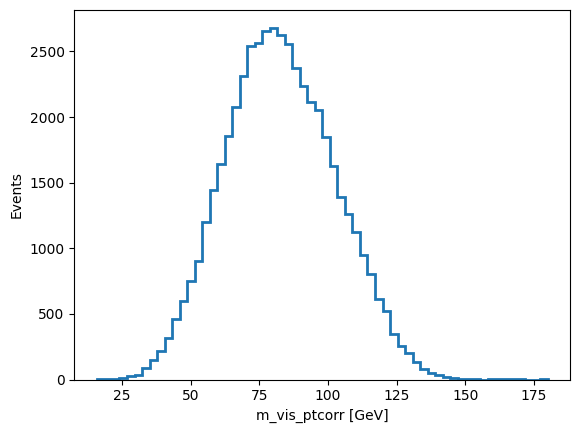

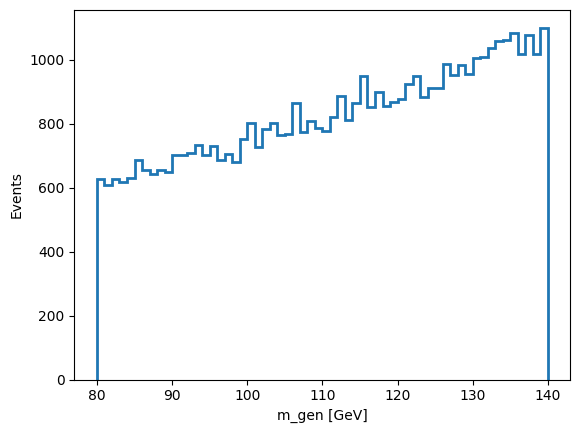

In [200]:
# taglio in massa -> su m_target
print("Before cut:", len(df_flat_event))

df_flat_cut = df_flat_event[
    (df_flat_event["m_gen"] >= 80.0) &
    (df_flat_event["m_gen"] <= 140.0)
].copy()

print("After cut:", len(df_flat_cut))

# just checking 
import matplotlib.pyplot as plt

plt.hist(df_flat_cut["m_vis_ptcorr"], bins=60, histtype = 'step', linewidth = 2, density = False)   
plt.xlabel("m_vis_ptcorr [GeV]")
plt.ylabel("Events")
plt.show()


plt.hist(df_flat_cut["m_gen"], bins=60, histtype = 'step', linewidth = 2, density = False)  # -> Me lo aspetto quasi piatto
plt.xlabel("m_gen [GeV]")
plt.ylabel("Events")
plt.show()

In [201]:
# Preparazione per training 

eps = 1e-8

# Li rinomino coerentemente con il precedente modello :
df_flat_cut["tau1_pt_gen"] = df_flat_cut["gen_tau1_pt"]
df_flat_cut["tau2_pt_gen"] = df_flat_cut["gen_tau2_pt"]

# --- target: fattore di correzione ---
df_flat_cut["tau1_corr"] = df_flat_cut["tau1_pt_gen"] / np.clip(df_flat_cut["tau1_pt_reco_corrPNet"], eps, None)
df_flat_cut["tau2_corr"] = df_flat_cut["tau2_pt_gen"] / np.clip(df_flat_cut["tau2_pt_reco_corrPNet"], eps, None)

y_cols = ["tau1_corr", "tau2_corr"]

# Next steps: Pre-Training su Sample Flat e Fine-Tuning su Sample Fisici

---

# BLOCCO A — Pre-Training con Scaling (X globale + Y globale)

## A1. Pre-Training sui Sample Flat

Dataset: `df_flat_cut`

- Suddivisione: 80 / 10 / 10
- Normalizzazione:
  - X: StandardScaler globale (fittato solo sul train flat)
  - Y: StandardScaler globale (fittato solo sul train flat)
- Addestramento del modello Conditional Flow Matching
- Output:
  - Modello pre-addestrato (`model_flat_scaled`)
  - Scaler dei flat (`scalers_flat`: Xg + Yg)

---

## A2. Fine-Tuning sui Sample Fisici (DY + Higgs)

Dataset: `df_all` (unbalanced)

La suddivisione train/val/test è la stessa già utilizzata in precedenza, così da garantire confronti diretti con i training "from scratch".

Inizializzazione del modello:
- Pesi caricati dal pre-training sui flat.

### A2a. Fine-Tuning mantenendo gli scaler dei flat

- X globale + Y globale (usando gli scaler calcolati sui flat)
- Si aggiornano solo i pesi del modello
- Nessuna nuova normalizzazione sui dati fisici

---

### A2b. Fine-Tuning con nuovi scaler calcolati sui sample fisici

In questo caso si ricalcolano gli scaler sul train fisico (`df_all` train).

Si considerano due configurazioni:

- X globale + Y globale (scaler fittati su DY + Higgs)
- X globale + Y locale (scaler Y separati per DY e Higgs)

---

# BLOCCO B — Pre-Training senza Scaling

## B1. Pre-Training sui Flat senza Normalizzazione

Dataset: `df_flat_cut`

- Nessuno scaling su X
- Nessuno scaling su Y

Output:
- Modello pre-addestrato senza scaling (`model_flat_noscale`)

---

## B2. Fine-Tuning sui Sample Fisici a partire dal Modello Senza Scaling

Si considerano le seguenti configurazioni:

- Nessuno scaling (coerente con il pre-training)
- X globale + Y globale (scaler fittati su DY + Higgs)
- X globale + Y locale (scaler Y separati per classe)

In [202]:
# A1

# ============================================================
# SPLIT FLAT
# ============================================================
df_train_f, df_val_f, df_test_f = split_80_10_10(df_flat_cut, seed=42)

print("Flat split sizes:")
print("Train:", len(df_train_f))
print("Val  :", len(df_val_f))
print("Test :", len(df_test_f))

Flat split sizes:
Train: 39838
Val  : 4980
Test : 4980


In [203]:
# ============================================================
# PREP ARRAYS FLAT (X global + Y global)
# ============================================================
Xtr_f, Xva_f, Xte_f, ytr_f, yva_f, yte_f, scalers_flat = prepare_arrays_scaled_global(
    df_train_f,
    df_val_f,
    df_test_f,
    train_cols=train_cols,
    y_cols=y_cols,
)

# ============================================================
# PRE-TRAINING CFM (FLAT)
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

dl_tr = DataLoader(
    TabularFMDataset(Xtr_f, ytr_f),
    batch_size=1024,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

dl_va = DataLoader(
    TabularFMDataset(Xva_f, yva_f),
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

model_flat = ConditionalVelocityField(
    x_dim=ytr_f.shape[1],
    context_dim=Xtr_f.shape[1],
    hidden=(256,256,256),
    time_embed_dim=64,
    dropout=0.0,
).to(device)

optimizer = torch.optim.AdamW(model_flat.parameters(), lr=2e-4)
stopper = EarlyStopping(patience=30, min_delta=1e-4)

EPOCHS = 300
hist_tr_f, hist_va_f = [], []

for ep in range(1, EPOCHS + 1):

    model_flat.train()
    tr_losses = []
    for xb, yb in dl_tr:
        xb = xb.to(device)
        yb = yb.to(device)

        loss = fm_loss(model_flat, xb, yb, device=device)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        tr_losses.append(loss.item())

    tr_loss = float(np.mean(tr_losses))

    model_flat.eval()
    va_losses = []
    with torch.no_grad():
        for xb, yb in dl_va:
            xb = xb.to(device)
            yb = yb.to(device)

            loss = fm_loss(model_flat, xb, yb, device=device)
            va_losses.append(loss.item())

    va_loss = float(np.mean(va_losses))

    hist_tr_f.append(tr_loss)
    hist_va_f.append(va_loss)

    if ep % 20 == 0 or ep == 1:
        print(f"[FLAT pretrain | ep {ep:03d}] train={tr_loss:.6f} val={va_loss:.6f}")

    if stopper.step(va_loss, model_flat):
        print(f"Early stopping at epoch {ep}")
        break

if stopper.best_state is not None:
    model_flat.load_state_dict(stopper.best_state)

res_flat_scaled = {
    "model": model_flat,
    "device": device,
    "scalers": scalers_flat,
    "loss_history": {"train": hist_tr_f, "val": hist_va_f},
    "train_cols": train_cols,
    "y_cols": y_cols,
}

[FLAT pretrain | ep 001] train=1.941126 val=1.849618
[FLAT pretrain | ep 020] train=1.124824 val=1.096613
[FLAT pretrain | ep 040] train=1.065376 val=1.105864
[FLAT pretrain | ep 060] train=1.048868 val=1.074549
[FLAT pretrain | ep 080] train=1.025841 val=1.035214
Early stopping at epoch 86


In [204]:
# A2 
# ============================================================
# PREP DY+H USING FLAT SCALERS
# ============================================================

x_scaler_flat = scalers_flat["x_scaler"]
y_scaler_flat = scalers_flat["y_scaler"]

def transform_with_flat_scalers(df, x_scaler, y_scaler):
    X_raw = df[train_cols].to_numpy(dtype=np.float32)
    y_raw = df[y_cols].to_numpy(dtype=np.float32)

    X = x_scaler.transform(X_raw).astype(np.float32)
    y = y_scaler.transform(y_raw).astype(np.float32)

    return X, y

Xtr_dy, ytr_dy = transform_with_flat_scalers(df_train, x_scaler_flat, y_scaler_flat)
Xva_dy, yva_dy = transform_with_flat_scalers(df_val,   x_scaler_flat, y_scaler_flat)

# ============================================================
# FINE-TUNING (SCALERS FROM FLAT)
# ============================================================

model_ft = ConditionalVelocityField(
    x_dim=ytr_dy.shape[1],
    context_dim=Xtr_dy.shape[1],
    hidden=(256,256,256),
    time_embed_dim=64,
    dropout=0.0,
).to(device)

model_ft.load_state_dict(res_flat_scaled["model"].state_dict())

optimizer = torch.optim.AdamW(model_ft.parameters(), lr=1e-4)
stopper = EarlyStopping(patience=30, min_delta=1e-4)

dl_tr = DataLoader(TabularFMDataset(Xtr_dy, ytr_dy), batch_size=1024, shuffle=True)
dl_va = DataLoader(TabularFMDataset(Xva_dy, yva_dy), batch_size=1024, shuffle=False)

hist_tr_ft, hist_va_ft = [], []

for ep in range(1, EPOCHS + 1):

    model_ft.train()
    tr_losses = []
    for xb, yb in dl_tr:
        xb = xb.to(device)
        yb = yb.to(device)

        loss = fm_loss(model_ft, xb, yb, device=device)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        tr_losses.append(loss.item())

    tr_loss = float(np.mean(tr_losses))

    model_ft.eval()
    va_losses = []
    with torch.no_grad():
        for xb, yb in dl_va:
            xb = xb.to(device)
            yb = yb.to(device)
            loss = fm_loss(model_ft, xb, yb, device=device)
            va_losses.append(loss.item())

    va_loss = float(np.mean(va_losses))

    hist_tr_ft.append(tr_loss)
    hist_va_ft.append(va_loss)

    if ep % 20 == 0 or ep == 1:
        print(f"[FT flat-scalers | ep {ep:03d}] train={tr_loss:.6f} val={va_loss:.6f}")

    if stopper.step(va_loss, model_ft):
        print("Early stopping fine-tuning")
        break

if stopper.best_state is not None:
    model_ft.load_state_dict(stopper.best_state)

res_ft_flat_scalers = {
    "model": model_ft,
    "device": device,
    "scalers": scalers_flat,
    "loss_history": {"train": hist_tr_ft, "val": hist_va_ft},
    "train_cols": train_cols,
    "y_cols": y_cols,
}

[FT flat-scalers | ep 001] train=0.774419 val=0.758494
[FT flat-scalers | ep 020] train=0.718388 val=0.736899
[FT flat-scalers | ep 040] train=0.699413 val=0.699875
[FT flat-scalers | ep 060] train=0.690022 val=0.696592
[FT flat-scalers | ep 080] train=0.682183 val=0.675216
[FT flat-scalers | ep 100] train=0.682461 val=0.688696
[FT flat-scalers | ep 120] train=0.671072 val=0.673879
[FT flat-scalers | ep 140] train=0.666603 val=0.667778
[FT flat-scalers | ep 160] train=0.645936 val=0.656556
[FT flat-scalers | ep 180] train=0.639433 val=0.636147
[FT flat-scalers | ep 200] train=0.625213 val=0.632805
Early stopping fine-tuning


In [205]:
# ============================================================
# FINE-TUNING su DY+H (df_train/df_val/df_test già definiti):
#   1) nuovi scaler fisici: Xg+Yg
#   2) nuovi scaler fisici: Xg+Ylocal
#   3) nessuno scaling
# Inizializzazione pesi: res_flat_scaled["model"]
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS_FT = 300
BATCH = 1024
PATIENCE = 30
MIN_DELTA = 1e-4

def finetune_from_pretrained(
    Xtr, ytr, Xva, yva,
    pretrained_res,
    scalers_dict,
    lr=1e-4,
    tag="FT",
):
    # loaders
    dl_tr = DataLoader(TabularFMDataset(Xtr, ytr), batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=True)
    dl_va = DataLoader(TabularFMDataset(Xva, yva), batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

    # build model (same architecture)
    model = ConditionalVelocityField(
        x_dim=ytr.shape[1],
        context_dim=Xtr.shape[1],
        hidden=(256, 256, 256),
        time_embed_dim=64,
        dropout=0.0,
    ).to(DEVICE)

    # load pretrained weights
    model.load_state_dict(pretrained_res["model"].state_dict())

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    stopper = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)

    hist_tr, hist_va = [], []

    for ep in range(1, EPOCHS_FT + 1):

        # ---- TRAIN ----
        model.train()
        tr_losses = []
        for xb, yb in dl_tr:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            loss = fm_loss(model, xb, yb, device=DEVICE)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        tr_loss = float(np.mean(tr_losses))

        # ---- VAL ----
        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in dl_va:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                loss = fm_loss(model, xb, yb, device=DEVICE)
                va_losses.append(loss.item())
        va_loss = float(np.mean(va_losses))

        hist_tr.append(tr_loss)
        hist_va.append(va_loss)

        if ep % 20 == 0 or ep == 1:
            print(f"[{tag} | ep {ep:03d}/{EPOCHS_FT}] train={tr_loss:.6f}  val={va_loss:.6f}")

        if stopper.step(va_loss, model):
            print(f"[{tag}] Early stopping at epoch {ep} (best val={stopper.best:.6f})")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    res_ft = {
        "model": model,
        "device": DEVICE,
        "scalers": scalers_dict,
        "df_splits": (df_train, df_val, df_test),
        "loss_history": {"train": hist_tr, "val": hist_va},
        "train_cols": train_cols,
        "y_cols": y_cols,
    }
    return res_ft


# ============================================================
# (1) FT con nuovi scaler fisici: Xg + Yg
# ============================================================
Xtr_g, Xva_g, Xte_g, ytr_g, yva_g, yte_g, scalers_phys_global = prepare_arrays_scaled_global(
    df_train, df_val, df_test,
    train_cols=train_cols,
    y_cols=y_cols,
)

res_ft_phys_global = finetune_from_pretrained(
    Xtr_g, ytr_g, Xva_g, yva_g,
    pretrained_res=res_flat_scaled,
    scalers_dict=scalers_phys_global,
    lr=1e-4,
    tag="FT phys Xg+Yg"
)


# ============================================================
# (2) FT con nuovi scaler fisici: Xg + Ylocal
# ============================================================
Xtr_m, Xva_m, Xte_m, ytr_m, yva_m, yte_m, scalers_phys_mixed = prepare_arrays_scaled_mixed(
    df_train, df_val, df_test,
    train_cols=train_cols,
    y_cols=y_cols,
    class_col="class",
)

res_ft_phys_mixed = finetune_from_pretrained(
    Xtr_m, ytr_m, Xva_m, yva_m,
    pretrained_res=res_flat_scaled,
    scalers_dict=scalers_phys_mixed,
    lr=1e-4,
    tag="FT phys Xg+Ylocal"
)


# ============================================================
# (3) FT senza scaling 
# ============================================================
Xtr_n, Xva_n, Xte_n, ytr_n, yva_n, yte_n, scalers_noscale = prepare_arrays_noscale(
    df_train, df_val, df_test,
    train_cols=train_cols,
    y_cols=y_cols,
)

res_ft_noscale = finetune_from_pretrained(
    Xtr_n, ytr_n, Xva_n, yva_n,
    pretrained_res=res_flat_scaled,
    scalers_dict=scalers_noscale,   # {"mode":"NO_SCALING"} (da prepare_arrays_noscale)
    lr=5e-5,                        
    tag="FT NO scaling"
)


[FT phys Xg+Yg | ep 001/300] train=1.219651  val=1.191373
[FT phys Xg+Yg | ep 020/300] train=1.126904  val=1.126123
[FT phys Xg+Yg | ep 040/300] train=1.093661  val=1.092227
[FT phys Xg+Yg | ep 060/300] train=1.073917  val=1.085088
[FT phys Xg+Yg | ep 080/300] train=1.061902  val=1.058164
[FT phys Xg+Yg | ep 100/300] train=1.045650  val=1.021085
[FT phys Xg+Yg | ep 120/300] train=1.024304  val=1.026752
[FT phys Xg+Yg | ep 140/300] train=1.010008  val=1.005759
[FT phys Xg+Yg | ep 160/300] train=0.993843  val=0.992685
[FT phys Xg+Yg | ep 180/300] train=0.974411  val=0.968911
[FT phys Xg+Yg | ep 200/300] train=0.944141  val=0.931422
[FT phys Xg+Yg | ep 220/300] train=0.933216  val=0.949298
[FT phys Xg+Yg | ep 240/300] train=0.917286  val=0.928572
[FT phys Xg+Yg | ep 260/300] train=0.915822  val=0.911318
[FT phys Xg+Yg | ep 280/300] train=0.905114  val=0.918601
[FT phys Xg+Yg | ep 300/300] train=0.893920  val=0.906192
[FT phys Xg+Ylocal | ep 001/300] train=1.175241  val=1.170989
[FT phys X

In [206]:
# ============================================================
# CONTROL PLOTS (only FM masses, no reco/target) + LOSS
# Compare fine-tuning variants:
#   - res_ft_flat_scalers   (FT using flat scalers)  
#   - res_ft_phys_global    (FT with physical scalers: Xg+Yg)
#   - res_ft_phys_mixed     (FT with physical scalers: Xg+Ylocal)
#   - res_ft_noscale        (FT with no scaling)
#
# Mass plots: 2x2 grid (TRAIN/TEST x DY/Higgs), only FM curves.
# Loss plots: one figure per run 
# ============================================================
# -----------------------
# Helpers: DY/Higgs masks + robust range
# -----------------------
def infer_masks(df, class_col="class"):
    c = df[class_col]
    if c.dtype == object:
        s = c.astype(str).str.lower()
        m_dy = s.str.contains("dy") | s.str.contains("drell")
        m_h  = s.str.contains("higgs")
        if m_h.sum() == 0:
            m_h = s.str.contains("h")
        return m_dy.to_numpy(), m_h.to_numpy()
    vals = np.asarray(c)
    uniq = np.unique(vals)
    if len(uniq) == 2:
        return (vals == np.min(uniq)), (vals == np.max(uniq))
    raise ValueError("Cannot infer DY/Higgs masks; check 'class' column.")

def robust_mass_range(arrs, qlo=0.5, qhi=99.5):
    allm = np.concatenate([a[np.isfinite(a)] for a in arrs if a is not None])
    lo = np.percentile(allm, qlo)
    hi = np.percentile(allm, qhi)
    return (float(lo), float(hi))

# -----------------------
# Predictor dispatch (based on res["scalers"]["mode"])
# -----------------------
def predict_tau_corr_auto(df, res, train_cols, y_cols, n_steps=60, batch_size=8192):
    mode = res.get("scalers", {}).get("mode", "NO_SCALING")
    if mode == "NO_SCALING":
        return predict_tau_corr_general(df, res, train_cols, y_cols, n_steps=n_steps, batch_size=batch_size)
    if mode == "X_GLOBAL__Y_GLOBAL":
        return predict_tau_corr_general_scaled_global(df, res, train_cols, y_cols, n_steps=n_steps, batch_size=batch_size)
    # mixed/local target scaling
    return predict_tau_corr_general_scaled_mixed(df, res, train_cols, y_cols, n_steps=n_steps, batch_size=batch_size)

def fm_mass_array(df, res, out_col="inv_mass_FM_tmp", n_steps=60, clip_corr=(0.0, 5.0)):
    pred = predict_tau_corr_auto(df, res, train_cols, y_cols, n_steps=n_steps, batch_size=8192)
    dfm  = add_fm_mass_columns(df, pred, out_mass_col=out_col, clip_corr=clip_corr)
    return dfm[out_col].to_numpy()

# -----------------------
# MASS PLOT: 2x2 (TRAIN/TEST x DY/Higgs), FM-only curves
# -----------------------
def plot_fm_masses_2x2(dfs, masses_tr, masses_te, labels,
                      class_col="class", bins=80, m_range=None, density=True, suptitle="FM mass comparison"):
    # dfs: dict with keys "train","test" giving base dfs (for masks)
    df_tr = dfs["train"]
    df_te = dfs["test"]

    m_dy_tr, m_h_tr = infer_masks(df_tr, class_col=class_col)
    m_dy_te, m_h_te = infer_masks(df_te, class_col=class_col)

    if m_range is None:
        m_range = robust_mass_range(masses_tr + masses_te)

    fig, axs = plt.subplots(2, 2, figsize=(13.5, 8), sharex=True, sharey=True)
    fig.suptitle(suptitle)

    panels = [
        ("TRAIN — DY",    m_dy_tr, masses_tr, axs[0,0]),
        ("TRAIN — Higgs", m_h_tr,  masses_tr, axs[0,1]),
        ("TEST — DY",     m_dy_te, masses_te, axs[1,0]),
        ("TEST — Higgs",  m_h_te,  masses_te, axs[1,1]),
    ]

    for title, mask, masses_list, ax in panels:
        for arr, lab in zip(masses_list, labels):
            a = arr[mask]
            a = a[np.isfinite(a)]
            ax.hist(a, bins=bins, range=m_range, histtype="step", density=density, linewidth=1.7, label=lab)
        ax.set_title(title)
        ax.grid(True, alpha=0.25)

    for ax in axs[1,:]:
        ax.set_xlabel("Invariant mass")
    for ax in axs[:,0]:
        ax.set_ylabel("Density" if density else "Counts")

    handles, labs = axs[0,0].get_legend_handles_labels()
    fig.legend(handles, labs, loc="upper center", ncol=min(4, len(labels)), frameon=False, bbox_to_anchor=(0.5, 0.95))
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
    #return fig


runs = []
labels = []

if "res_ft_flat_scalers" in globals():
    runs.append(res_ft_flat_scalers)
    labels.append("FT flat scalers (Xg+Yg)")

runs += [res_ft_phys_global, res_ft_phys_mixed, res_ft_noscale]
labels += ["FT phys scalers (Xg+Yg)", "FT phys scalers (Xg+Ylocal)", "FT no scaling"]

# ============================================================
# Compute FM masses (TRAIN + TEST) for each run
# ============================================================
df_train_phys = df_train
df_val_phys   = df_val
df_test_phys  = df_test

masses_tr = []
masses_te = []
for i, r in enumerate(runs):
    masses_tr.append(fm_mass_array(df_train_phys, r, out_col=f"inv_mass_FM_tr_{i}", n_steps=60, clip_corr=(0.0,5.0)))
    masses_te.append(fm_mass_array(df_test_phys,  r, out_col=f"inv_mass_FM_te_{i}", n_steps=60, clip_corr=(0.0,5.0)))

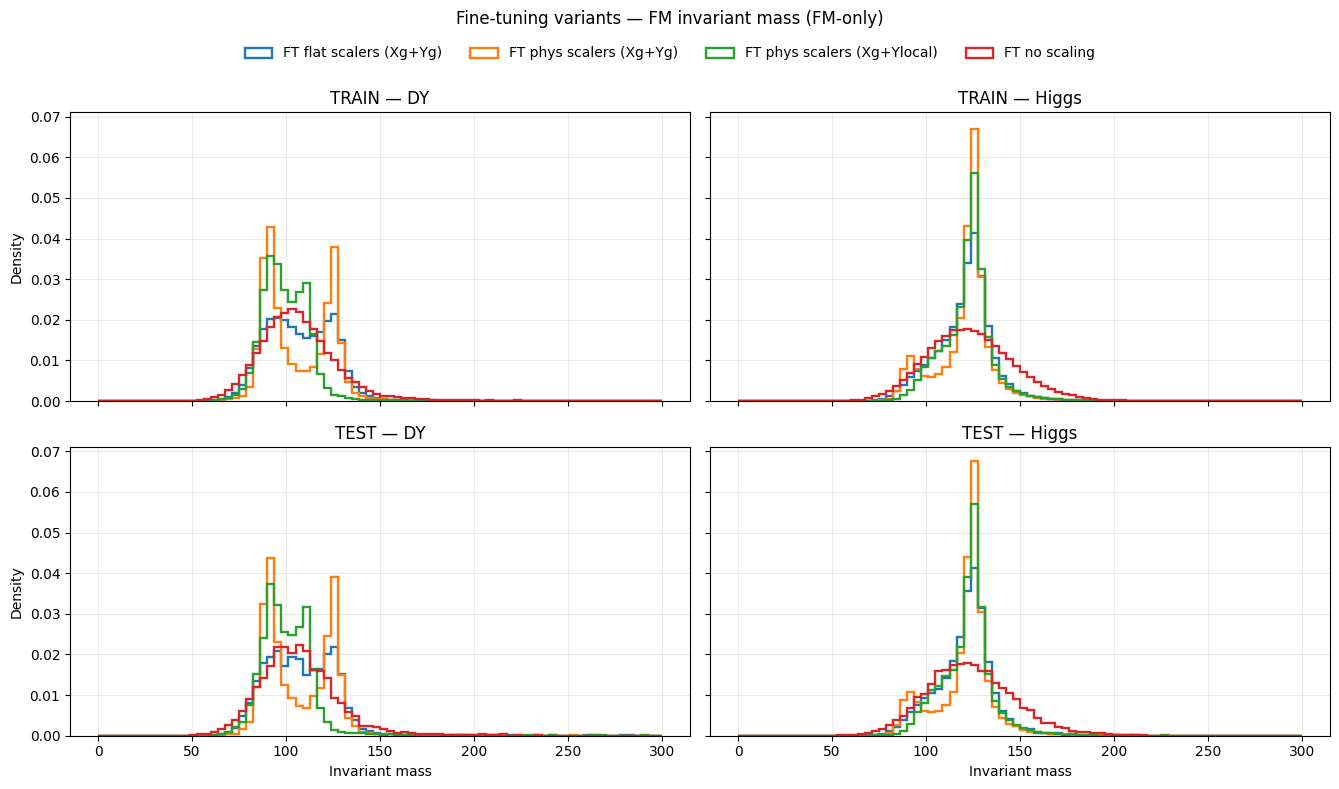

In [207]:
plot_fm_masses_2x2(
    dfs={"train": df_train_phys, "test": df_test_phys},
    masses_tr=masses_tr,
    masses_te=masses_te,
    labels=labels,
    class_col="class",
    bins=80,
    m_range=(0,300),
    density=True,
    suptitle="Fine-tuning variants — FM invariant mass (FM-only)"
)

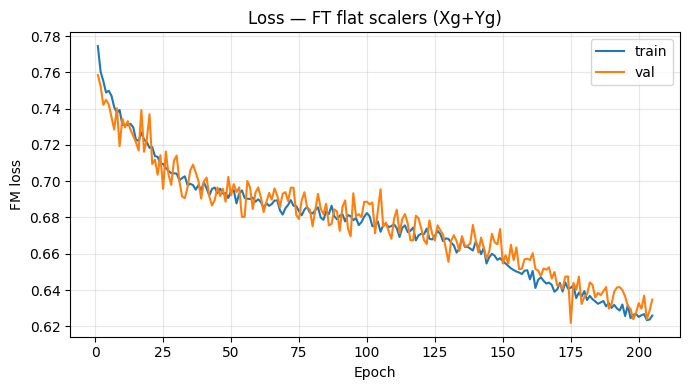

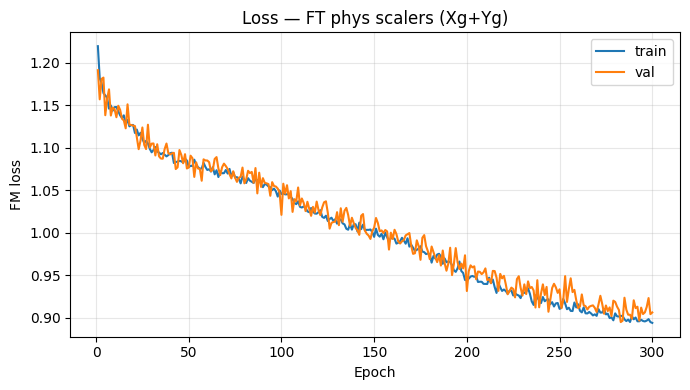

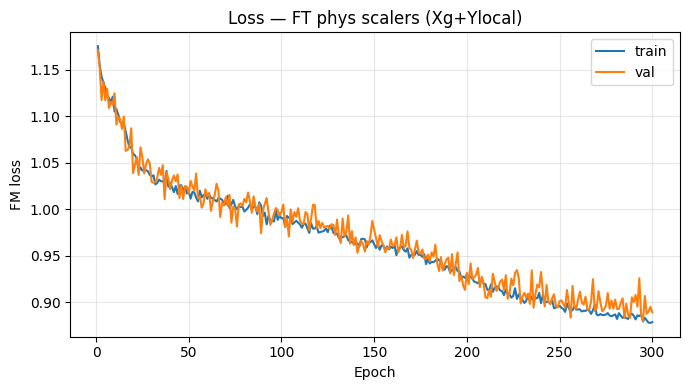

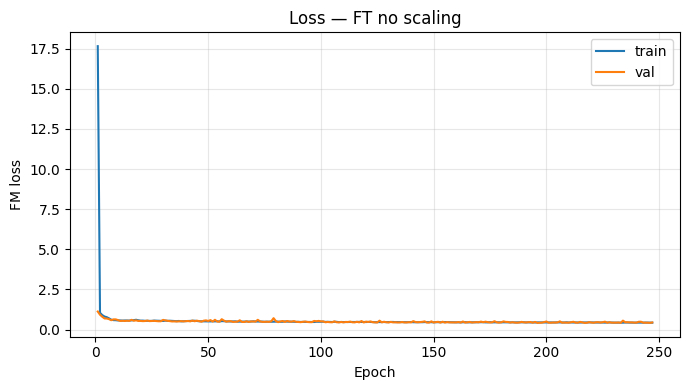

In [208]:
# ============================================================
# LOSS PLOTS (one per run)
# ============================================================
def plot_loss(res, title):
    tr = np.asarray(res["loss_history"]["train"], dtype=float)
    va = np.asarray(res["loss_history"]["val"], dtype=float)
    e = np.arange(1, len(tr) + 1)
    plt.figure(figsize=(7,4))
    plt.plot(e, tr, label="train")
    plt.plot(e, va, label="val")
    plt.xlabel("Epoch")
    plt.ylabel("FM loss")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for lab, r in zip(labels, runs):
    plot_loss(r, f"Loss — {lab}")
